# AirGuard-LK
## Multi-Stage Industrial AI for Compressed-Air Early Watch, Warning and Fault Confirmation

**OctWave 3.0 Final Round — Industrial AI & Intelligence**

**Primary Track:** Industrial Safety, Reliability & Resilience  
**Secondary Relevance:** Energy Efficiency & Sustainable Industry

### Purpose of this notebook

This is the **single comprehensive submission notebook** for AirGuard-LK. It contains the core data audit, causal preprocessing, feature engineering, validation logic, baseline and nonlinear experiments, deep-learning challengers, explainability, post-hoc early-watch investigations, final multi-stage operating logic, limitations, reproducibility controls and claims.

The notebook is intentionally explicit about **which results were frozen before F04** and which analyses were performed **after F04 had already been examined**. This distinction prevents retrospective improvements from being presented as pristine holdout evidence.

The submitted dataset is **MetroPT-3**, an international railway air-production/compressor dataset. AirGuard-LK is designed for future adaptation to Sri Lankan compressed-air systems; **no Sri Lankan validation claim is made**.


## Executive Summary

AirGuard-LK investigates how industrial AI can detect abnormal compressed-air/compressor behaviour while avoiding the misleading optimism created by random row splitting in highly correlated time-series data.

The project uses **MetroPT-3**: 1,516,948 timestamped observations from February–September 2020, 15 sensor/state channels and four documented air-leak fault events (F01–F04). The workflow audits sampling gaps, constructs causal features, prevents long-gap leakage and validates across later **physical fault events** rather than random sensor rows.

### Primary frozen experiment

The original pre-fault objective was tested first. Pre-event signatures did not transfer consistently across independent development events, so the primary validated task was narrowed to **fault-state detection**.

The selected frozen model was **LightGBM Current**, using 71 current-minute/state-aware features.

Development:
- F02 PR-AUC: **0.8556**
- F03 PR-AUC: **0.9859**
- mean PR-AUC: **0.9208**
- development faults detected: **2/2**
- median persistent-alert delay: **1 minute**
- mean false-alarm episodes/day: **0.0362**
- worst-fold false-alarm episodes/day: **0.0724**

Frozen F04:
- PR-AUC: **0.2754**
- detected: **yes**
- persistent-alert delay: **+150 minutes**
- false-alarm episodes: **0**

The F04 result is retained as the primary chronological holdout result rather than hidden.

### Post-hoc model-family investigation

After the F04 limitation was known, several targeted analyses were conducted and are explicitly labelled **post-hoc**:

1. An **ASPIRE-inspired raw-sequence Transformer** retained ~10-second information in 100-sample windows. At 20 epochs it achieved strong active-F04 fault recognition (F1 **0.897**, AP **0.985**) but produced **no F04 pre-fault warning**.
2. A **normal-only global Isolation Forest** showed that abnormal F04 behaviour could be flagged much earlier, including a strict new early-watch episode **945 minutes (15 h 45 min) before F04**, but with high nuisance occupancy.
3. **State-conditioned anomaly models** reduced alert occupancy but fragmented alerts.
4. A fixed **global AND state-conditioned consensus** preserved the F04 early-watch signal.
5. A development-selected **30-minute sustained escalation rule** converted the sensitive watch signal into a more selective Warning state. It retained strict early warnings on F01–F03, and on retrospective F04 evaluation produced the Warning at **+40 minutes**, improving response by **110 minutes** relative to frozen LightGBM confirmation.

### Final system interpretation

AirGuard-LK therefore separates three operational concepts:

- **EARLY WATCH:** sensitive novelty/anomaly awareness; not a confirmed fault prediction.
- **WARNING:** sustained abnormality that warrants human inspection.
- **FAULT CONFIRMATION:** state-aware LightGBM evidence resembling documented fault conditions.

The final contribution is not a claim that every leak is predicted before onset. It is a **causal, event-aware, explainable, human-in-the-loop industrial monitoring architecture** that distinguishes early novelty detection from higher-specificity fault confirmation.


# 1. Execution Guide

The final submitted notebook should be opened with outputs visible. Heavy experiment blocks are optional because executed result snapshots are retained for review.

Flags used in the core notebook:

- `REBUILD_FROM_RAW=True`: rebuild the causal one-minute table from MetroPT-3.
- `RUN_PREFAULT_REPRODUCTION=True`: rerun core pre-fault experiments.
- `RUN_FAULTSTATE_REPRODUCTION=True`: rerun the primary frozen LightGBM pipeline.
- `RUN_ENSEMBLE_CHALLENGERS=True`: rerun ensemble challengers.
- `RUN_DEEP_CHALLENGERS=True`: rerun CNN / GRU challengers.
- `RUN_SHAP_REPRODUCTION=True`: recompute SHAP.
- `RUN_TRANSFORMER_REPRODUCTION=True`: optional raw-sequence Transformer rerun.
- `RUN_EARLYWATCH_REPRODUCTION=True`: optional normal-only anomaly rerun.

The primary submission claim comes from the **frozen LightGBM experiment**. Transformer/anomaly/consensus/escalation experiments are explicitly reported as **post-hoc system investigations** because F04 had already been examined when those model families were explored.


In [1]:
from pathlib import Path
import json
import hashlib
import math
import os
import platform
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    auc,
    precision_recall_curve,
    roc_auc_score,
    precision_recall_fscore_support,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

REBUILD_FROM_RAW = False
RUN_PREFAULT_REPRODUCTION = False
RUN_FAULTSTATE_REPRODUCTION = False
RUN_ENSEMBLE_CHALLENGERS = False
RUN_DEEP_CHALLENGERS = False
RUN_SHAP_REPRODUCTION = False
RUN_TRANSFORMER_REPRODUCTION = False
RUN_EARLYWATCH_REPRODUCTION = False

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("CPU threads:", os.cpu_count())
print("Seed:", SEED)

Python: 3.14.4
NumPy: 2.5.3
Pandas: 3.0.5
CPU threads: 20
Seed: 42


In [2]:
ROOT = Path.cwd()

if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

RAW_CANDIDATES = [
    ROOT / "Dataset" / "MetroPT3(AirCompressor).csv",
    ROOT / "data" / "raw" / "metropt3" / "MetroPT3(AirCompressor).csv",
    ROOT / "MetroPT3(AirCompressor).csv",
]

RAW_PATH = next((p for p in RAW_CANDIDATES if p.exists()), RAW_CANDIDATES[0])

CACHE_DIR = ROOT / "_airguard_notebook_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MINUTE_CACHE = CACHE_DIR / "metropt3_minute_current.pkl"
MASTER_CACHE = CACHE_DIR / "metropt3_master_inline.pkl"

print("Notebook root:", ROOT)
print("Raw CSV path:", RAW_PATH)
print("Raw CSV exists:", RAW_PATH.exists())

Notebook root: d:\OctWave3\AirGuard-LK
Raw CSV path: d:\OctWave3\AirGuard-LK\data\raw\metropt3\MetroPT3(AirCompressor).csv
Raw CSV exists: True


# 2. Industrial Problem and Research Context

Compressed air is widely used in industrial pneumatic actuators, packaging, material handling, workshops and automated machinery. A compressor can keep running while a leak or related fault increases duty cycle, energy demand and component wear.

The intended AirGuard-LK user is a:

- maintenance engineer;
- reliability engineer;
- plant / utilities engineer;
- factory energy manager.

The first deployment is intentionally **human-in-the-loop**, not autonomous shutdown.

## Existing technical approaches

1. **Engineering thresholds** — simple and interpretable, but operating-state variation can create nuisance alarms.
2. **Supervised tree models** — capture nonlinear interactions between pressure, state, temperature and current.
3. **Anomaly detection** — learns normal behaviour and flags novelty.
4. **Temporal feature engineering** — rolling levels, trends, volatility, duty cycles and transitions.
5. **Deep sequence models** — CNN / RNN / GRU / LSTM architectures that learn directly from windows.

## Methodological gap addressed

Thousands of neighbouring samples from one fault episode are highly correlated. A random row split can put almost identical samples from the same physical event into training and testing.

AirGuard-LK therefore uses **chronological event-wise validation**.

## Key references

1. Veloso, B., Ribeiro, R. P., Gama, J., et al. **The MetroPT dataset for predictive maintenance.** *Scientific Data* 9, 764 (2022). DOI: `10.1038/s41597-022-01877-3`.
2. **MetroPT-3 Dataset**, UCI Machine Learning Repository. DOI: `10.24432/C5VW3R`.
3. Davari, N. et al. **Predictive maintenance based on anomaly detection using deep learning for air production unit in railway industry.** IEEE DSAA (2021). DOI: `10.1109/DSAA53316.2021.9564181`.
4. Guha, S. & Datta, A. **ASPIRE: An Agentic Decision System for Early Equipment Failure Prediction and Intervention in Industrial IIoT.** *IEEE Access* 14 (2026), 105006–105031. DOI: `10.1109/ACCESS.2026.3711010`.
5. Ke, G. et al. **LightGBM: A Highly Efficient Gradient Boosting Decision Tree.** NeurIPS 2017.
6. Lundberg, S. M. & Lee, S.-I. **A Unified Approach to Interpreting Model Predictions.** NeurIPS 2017.


# 3. MetroPT-3 Dataset

AirGuard-LK uses the **MetroPT-3** dataset from the UCI Machine Learning Repository (DOI `10.24432/C5VW3R`; CC BY 4.0), associated with the Metro do Porto air-production/compressor predictive-maintenance research.

### Executed raw dataset characteristics

- **1,516,948 observations**
- time range: **2020-02-01 00:00:00 → 2020-09-01 03:59:50**
- **15 sensor/state channels**
- four documented **Air Leak** events: F01–F04
- typical sampling interval: approximately **10 seconds**

### Analogue signals
`TP2`, `TP3`, `H1`, `DV_pressure`, `Reservoirs`, `Oil_temperature`, `Motor_current`

### Digital / operating-state signals
`COMP`, `DV_eletric`, `Towers`, `MPG`, `LPS`, `Pressure_switch`, `Oil_level`, `Caudal_impulses`

The intended deployment context is Sri Lankan industry, but **MetroPT-3 is an international dataset**. The project does not claim Sri Lankan field validation.


In [3]:
ANALOG = [
    "TP2", "TP3", "H1", "DV_pressure",
    "Reservoirs", "Oil_temperature", "Motor_current",
]

DIGITAL = [
    "COMP", "DV_eletric", "Towers", "MPG",
    "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses",
]

EVENTS = pd.DataFrame([
    {"event_id": "F01", "start_time": "2020-04-18 00:00:00", "end_time": "2020-04-18 23:59:00"},
    {"event_id": "F02", "start_time": "2020-05-29 23:30:00", "end_time": "2020-05-30 06:00:00"},
    {"event_id": "F03", "start_time": "2020-06-05 10:00:00", "end_time": "2020-06-07 14:30:00"},
    {"event_id": "F04", "start_time": "2020-07-15 14:30:00", "end_time": "2020-07-15 19:00:00"},
])

EVENTS["start_time"] = pd.to_datetime(EVENTS["start_time"])
EVENTS["end_time"] = pd.to_datetime(EVENTS["end_time"])
EVENTS["duration_minutes"] = (
    (EVENTS["end_time"] - EVENTS["start_time"]).dt.total_seconds() / 60
)

EVENTS

,event_id,start_time,end_time,duration_minutes
0,F01,2020-04-18 00:00:00,2020-04-18 23:59:00,1439.0
1,F02,2020-05-29 23:30:00,2020-05-30 06:00:00,390.0
2,F03,2020-06-05 10:00:00,2020-06-07 14:30:00,3150.0
3,F04,2020-07-15 14:30:00,2020-07-15 19:00:00,270.0


## Independent-event limitation

The raw dataset contains more than 1.5 million sensor observations but only:

\[
\boxed{4\ \text{independent documented leak episodes}}
\]

This distinction is central. A thousand neighbouring minutes from F03 are not a thousand independent faults.

# 4. Raw-Data Audit

The audit checks:

- row count;
- timestamp validity;
- duplicates;
- missing values;
- sampling cadence;
- acquisition gaps.

Large acquisition gaps are **not interpolated**.

In [4]:
def load_raw_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"MetroPT-3 CSV not found at {path}. "
            "Place it in Dataset/ or update RAW_PATH."
        )

    df = pd.read_csv(path, low_memory=False)
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")

    required = ["timestamp", *ANALOG, *DIGITAL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    return df.sort_values("timestamp").reset_index(drop=True)


def audit_raw(df: pd.DataFrame) -> pd.DataFrame:
    delta = df["timestamp"].diff().dt.total_seconds()

    values = {
        "Raw observations": len(df),
        "Invalid timestamps": int(df["timestamp"].isna().sum()),
        "Duplicate timestamps": int(df["timestamp"].duplicated().sum()),
        "Missing sensor values": int(df[ANALOG + DIGITAL].isna().sum().sum()),
        "Median sampling interval (s)": float(delta.median()),
        "Mean sampling interval (s)": float(delta.mean()),
        "Maximum observed gap (s)": float(delta.max()),
        "Gaps > 30 s": int((delta > 30).sum()),
        "Gaps > 60 s": int((delta > 60).sum()),
        "Gaps > 300 s": int((delta > 300).sum()),
        "Gaps > 3600 s": int((delta > 3600).sum()),
    }

    return pd.DataFrame({"Metric": values.keys(), "Value": values.values()})


if RAW_PATH.exists():
    raw = load_raw_csv(RAW_PATH)
    display(audit_raw(raw))
else:
    raw = None
    print("Raw CSV not found. Methodology remains visible.")

,Metric,Value
0,Raw observations,1.516948e+06
1,Invalid timestamps,0.000000e+00
2,Duplicate timestamps,0.000000e+00
3,Missing sensor values,0.000000e+00
4,Median sampling interval (s),1.000000e+01
5,Mean sampling interval (s),1.214122e+01
6,Maximum observed gap (s),1.729180e+05
7,Gaps > 30 s,3.310000e+02
8,Gaps > 60 s,3.310000e+02
9,Gaps > 300 s,2.750000e+02


### Executed development audit

| Metric | Result |
|---|---:|
| Raw rows | 1,516,948 |
| Invalid timestamps | 0 |
| Duplicate timestamps | 0 |
| Missing sensor values | 0 |
| Median cadence | 10 s |
| Gaps > 30 s | 331 |

The gap structure is why the pipeline resets temporal history across acquisition breaks.

,Threshold_s,Count
0,10,51147
1,20,351
2,30,331
3,60,331
4,120,327
5,300,275
6,600,230
7,3600,160


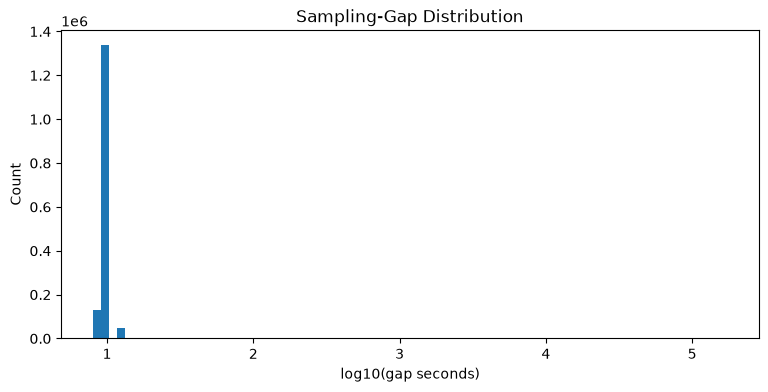

In [5]:
if raw is not None:
    dt = raw["timestamp"].diff().dt.total_seconds()

    gap_summary = pd.DataFrame({
        "Threshold_s": [10, 20, 30, 60, 120, 300, 600, 3600],
        "Count": [int((dt > t).sum()) for t in [10, 20, 30, 60, 120, 300, 600, 3600]],
    })
    display(gap_summary)

    positive = dt[dt > 0].dropna()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(np.log10(positive), bins=80)
    ax.set_xlabel("log10(gap seconds)")
    ax.set_ylabel("Count")
    ax.set_title("Sampling-Gap Distribution")
    plt.show()

# 5. Operating-State EDA

EDA showed strong dependencies between operating-state channels and analogue sensor behaviour.

Development observations included approximately:

- `COMP ≈ MPG` agreement ≈ 99.6%;
- `COMP` and `DV_eletric` usually opposite;
- `TP3` and `Reservoirs` correlation ≈ 0.999993.

This motivated **state-aware features**, not just independent sensor thresholds.

In [6]:
if raw is not None:
    state_summary = pd.DataFrame({
        "Metric": [
            "COMP == MPG fraction",
            "COMP != DV_eletric fraction",
            "TP3 / Reservoirs correlation",
            "Mean |TP3 - Reservoirs|",
            "P95 |TP3 - Reservoirs|",
        ],
        "Value": [
            float((raw["COMP"] == raw["MPG"]).mean()),
            float((raw["COMP"] != raw["DV_eletric"]).mean()),
            float(raw["TP3"].corr(raw["Reservoirs"])),
            float((raw["TP3"] - raw["Reservoirs"]).abs().mean()),
            float((raw["TP3"] - raw["Reservoirs"]).abs().quantile(0.95)),
        ],
    })
    display(state_summary)

    display(
        raw.groupby("COMP")[["TP2", "H1", "Motor_current", "DV_pressure", "Oil_temperature"]]
        .agg(["median", "mean", "std"])
    )

,Metric,Value
0,COMP == MPG fraction,0.995707
1,COMP != DV_eletric fraction,0.988950
2,TP3 / Reservoirs correlation,0.999993
3,Mean |TP3 - Reservoirs|,0.001862
4,P95 |TP3 - Reservoirs|,0.004000


TP2                         H1                     Motor_current  \
     median      mean       std median      mean       std        median   
COMP                                                                       
0.0   8.944  8.405803  2.300046 -0.012  0.232011  1.418336        5.8275   
1.0  -0.012 -0.003205  0.260330  8.968  8.997270  0.596728        0.0425   

                         DV_pressure                     Oil_temperature  \
          mean       std      median      mean       std          median   
COMP                                                                       
0.0   5.603786  1.013589      -0.018  0.423304  0.804462          65.575   
1.0   1.357910  1.786734      -0.020 -0.015605  0.131299          62.075   

                           
           mean       std  
COMP                       
0.0   66.094147  7.961112  
1.0   61.972112  5.967961

## Why this mattered

A raw sensor value can have different meaning under different compressor states.

The final model therefore includes interactions such as:

- `Motor_current_x_COMP0`
- `Motor_current_x_COMP1`
- `TP2_x_COMP0`
- `H1_x_COMP1`
- `COMP_MPG_mismatch_mean`
- `COMP_DV_equal_mean`

# 6. Event-Centred EDA

Early event-centred analysis showed that the four documented leak events were heterogeneous.

- **F01:** weak median pre-event signature.
- **F02:** pressure, H1, temperature and state changes.
- **F03:** subtle analogue changes but operating-state shifts.
- **F04:** comparatively strong standardized shifts in several variables.

This initially made pre-fault warning look promising. Later event-wise modelling showed that a precursor useful for one event did not necessarily transfer to another.

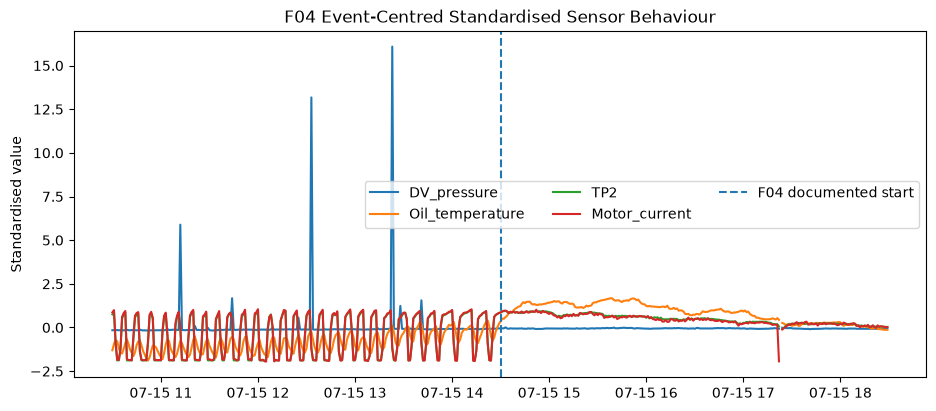

In [7]:
def event_window(df, event_id, hours_before=4, hours_after=4):
    ev = EVENTS.set_index("event_id").loc[event_id]
    lo = ev["start_time"] - pd.Timedelta(hours=hours_before)
    hi = ev["start_time"] + pd.Timedelta(hours=hours_after)
    return df[(df["timestamp"] >= lo) & (df["timestamp"] <= hi)].copy()


if raw is not None:
    w = event_window(raw, "F04")
    one_min = (
        w.set_index("timestamp")[["DV_pressure", "Oil_temperature", "TP2", "Motor_current"]]
        .resample("1min")
        .mean()
    )

    z = (one_min - one_min.mean()) / one_min.std().replace(0, 1)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for col in z.columns:
        ax.plot(z.index, z[col], label=col)

    start = EVENTS.set_index("event_id").loc["F04", "start_time"]
    ax.axvline(start, linestyle="--", label="F04 documented start")
    ax.set_title("F04 Event-Centred Standardised Sensor Behaviour")
    ax.set_ylabel("Standardised value")
    ax.legend(ncol=3)
    plt.show()

# 7. Causal One-Minute Aggregation

The raw ~10-second measurements are aggregated to one-minute rows.

## Causal availability convention

Measurements from `14:29:00` to `14:29:59` become a feature row timestamped **14:30**.

Thus \(X_t\) contains information available at or before \(t\).

## Gap-safe segmentation

A new acquisition segment begins when:

- wall-clock minute continuity breaks; or
- the current minute contains an incoming raw gap > 30 seconds.

Rolling history is never allowed to cross a segment boundary.

In [8]:
CURRENT_ENGINEERED = [
    "COMP_MPG_mismatch_mean",
    "COMP_DV_equal_mean",
    "TP3_Reservoir_abs_diff_mean",
    "TP3_Reservoir_abs_diff_max",
    "TP3_minus_Reservoirs_mean",
    "TP2_minus_TP3_mean",
    "H1_minus_TP3_mean",
    "TP2_minus_H1_mean",
    "Motor_current_x_COMP0",
    "Motor_current_x_COMP1",
    "TP2_x_COMP0",
    "H1_x_COMP1",
]


def build_causal_minute_table(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy().sort_values("timestamp").reset_index(drop=True)

    df["incoming_gap_s"] = df["timestamp"].diff().dt.total_seconds()
    df["minute_bucket"] = df["timestamp"].dt.floor("min")

    # Raw-level engineering relationships.
    df["COMP_MPG_mismatch"] = (df["COMP"] != df["MPG"]).astype(float)
    df["COMP_DV_equal"] = (df["COMP"] == df["DV_eletric"]).astype(float)
    df["TP3_Reservoir_abs_diff"] = (df["TP3"] - df["Reservoirs"]).abs()
    df["TP3_minus_Reservoirs"] = df["TP3"] - df["Reservoirs"]
    df["TP2_minus_TP3"] = df["TP2"] - df["TP3"]
    df["H1_minus_TP3"] = df["H1"] - df["TP3"]
    df["TP2_minus_H1"] = df["TP2"] - df["H1"]
    df["Motor_current_x_COMP0"] = df["Motor_current"] * (df["COMP"] == 0)
    df["Motor_current_x_COMP1"] = df["Motor_current"] * (df["COMP"] == 1)
    df["TP2_x_COMP0"] = df["TP2"] * (df["COMP"] == 0)
    df["H1_x_COMP1"] = df["H1"] * (df["COMP"] == 1)

    # Within-minute digital transitions.
    transition_cols = []
    for col in DIGITAL:
        name = f"{col}__transition"
        diff = df.groupby("minute_bucket")[col].diff()
        df[name] = diff.fillna(0).ne(0).astype(np.int8)
        transition_cols.append(name)

    g = df.groupby("minute_bucket", sort=True)

    # 35 analogue current-minute features.
    analog_agg = g[ANALOG].agg(["mean", "std", "min", "max", "last"])
    analog_agg.columns = [f"{c}_{stat}" for c, stat in analog_agg.columns]

    # 24 digital current-minute features.
    digital_mean = g[DIGITAL].mean().add_suffix("_mean")
    digital_last = g[DIGITAL].last().add_suffix("_last")
    trans = g[transition_cols].sum()
    trans.columns = [c.replace("__transition", "_transition_sum") for c in trans.columns]

    # 12 engineering/state features.
    eng = pd.DataFrame(index=analog_agg.index)
    eng["COMP_MPG_mismatch_mean"] = g["COMP_MPG_mismatch"].mean()
    eng["COMP_DV_equal_mean"] = g["COMP_DV_equal"].mean()
    eng["TP3_Reservoir_abs_diff_mean"] = g["TP3_Reservoir_abs_diff"].mean()
    eng["TP3_Reservoir_abs_diff_max"] = g["TP3_Reservoir_abs_diff"].max()
    eng["TP3_minus_Reservoirs_mean"] = g["TP3_minus_Reservoirs"].mean()
    eng["TP2_minus_TP3_mean"] = g["TP2_minus_TP3"].mean()
    eng["H1_minus_TP3_mean"] = g["H1_minus_TP3"].mean()
    eng["TP2_minus_H1_mean"] = g["TP2_minus_H1"].mean()
    eng["Motor_current_x_COMP0"] = g["Motor_current_x_COMP0"].mean()
    eng["Motor_current_x_COMP1"] = g["Motor_current_x_COMP1"].mean()
    eng["TP2_x_COMP0"] = g["TP2_x_COMP0"].mean()
    eng["H1_x_COMP1"] = g["H1_x_COMP1"].mean()

    minute = pd.concat(
        [analog_agg, digital_mean, digital_last, trans, eng],
        axis=1,
    )

    quality = pd.DataFrame(index=minute.index)
    quality["quality__sample_count"] = g.size()
    quality["quality__sampling_density"] = quality["quality__sample_count"] / 6.0
    quality["quality__low_sample_minute"] = (
        quality["quality__sample_count"] < 3
    ).astype(np.int8)
    quality["quality__max_incoming_raw_gap_s"] = g["incoming_gap_s"].max().fillna(0)
    quality["quality__raw_gap_over_30s"] = (
        quality["quality__max_incoming_raw_gap_s"] > 30
    ).astype(np.int8)

    # Shift to feature availability time.
    minute.index = pd.to_datetime(minute.index) + pd.Timedelta(minutes=1)
    quality.index = minute.index

    out = pd.concat([minute, quality], axis=1).reset_index()
    out = out.rename(columns={"minute_bucket": "timestamp", "index": "timestamp"})
    if "timestamp" not in out.columns:
        out = out.rename(columns={out.columns[0]: "timestamp"})

    minute_delta = out["timestamp"].diff().dt.total_seconds()
    segment_break = (
        out.index.to_series().eq(0)
        | minute_delta.ne(60)
        | out["quality__raw_gap_over_30s"].eq(1)
    )

    out["quality__segment_id"] = segment_break.cumsum().astype(int)
    out["quality__segment_position"] = (
        out.groupby("quality__segment_id").cumcount() + 1
    )

    # Shared strict eligibility used in development.
    out["quality__model_feature_eligible"] = (
        (out["quality__segment_position"] > 120)
        & out["quality__low_sample_minute"].eq(0)
        & out["quality__raw_gap_over_30s"].eq(0)
    ).astype(np.int8)

    return out

In [9]:
CURRENT_FEATURES = []

for sensor in ANALOG:
    for stat in ["mean", "std", "min", "max", "last"]:
        CURRENT_FEATURES.append(f"{sensor}_{stat}")

for sensor in DIGITAL:
    CURRENT_FEATURES.extend([
        f"{sensor}_mean",
        f"{sensor}_last",
        f"{sensor}_transition_sum",
    ])

CURRENT_FEATURES += CURRENT_ENGINEERED

assert len(CURRENT_FEATURES) == 71
print("Final current/state-aware feature count:", len(CURRENT_FEATURES))

Final current/state-aware feature count: 71


In [10]:
if REBUILD_FROM_RAW and raw is not None:
    minute_current = build_causal_minute_table(raw)
    minute_current.to_pickle(MINUTE_CACHE)
elif MINUTE_CACHE.exists():
    minute_current = pd.read_pickle(MINUTE_CACHE)
else:
    minute_current = None
    print("Set REBUILD_FROM_RAW=True to build the minute table.")

Set REBUILD_FROM_RAW=True to build the minute table.


### Executed minute-table development result

The original pipeline produced approximately:

- 252,720 one-minute rows;
- 332 acquisition segments;
- 71 current/state-aware features;
- a broader 264-feature temporal development bank;
- about 225,696 strict model-eligible rows.

# 8. Temporal Feature Engineering

The project also investigated longer temporal context using 5, 15, 30, 60 and 120 minute windows.

Feature families included:

- rolling analogue levels;
- trends;
- volatility;
- digital duty cycles;
- digital transition counts;
- operating-state interactions.

The important empirical result was:

> **Longer temporal features transferred less consistently across independent fault events than the simpler current/state-aware representation.**

In [11]:
TEMPORAL_WINDOWS = [5, 15, 30, 60, 120]


def add_temporal_features(current_df: pd.DataFrame) -> pd.DataFrame:
    """
    Segment-safe inline temporal implementation.
    """
    df = current_df.sort_values("timestamp").copy()
    base_cols = ["timestamp", "quality__segment_id", *CURRENT_FEATURES]
    work = df[base_cols].copy()

    parts = []

    for _, seg in work.groupby("quality__segment_id", sort=False):
        seg = seg.copy()

        for sensor in ANALOG:
            base = f"{sensor}_mean"

            for w in TEMPORAL_WINDOWS:
                seg[f"{sensor}_rollmean_{w}m"] = seg[base].rolling(
                    w, min_periods=w
                ).mean()
                seg[f"{sensor}_rollstd_{w}m"] = seg[base].rolling(
                    w, min_periods=w
                ).std()

            for w in [30, 120]:
                seg[f"{sensor}_slope_{w}m"] = (
                    seg[base] - seg[base].shift(w - 1)
                ) / max(w - 1, 1)

            seg[f"{sensor}_volatility_ratio_30m"] = (
                seg[base].rolling(5, min_periods=5).std()
                / seg[base].rolling(30, min_periods=30).std().replace(0, np.nan)
            )
            seg[f"{sensor}_volatility_ratio_120m"] = (
                seg[base].rolling(15, min_periods=15).std()
                / seg[base].rolling(120, min_periods=120).std().replace(0, np.nan)
            )

        for sensor in DIGITAL:
            for w in TEMPORAL_WINDOWS:
                seg[f"{sensor}_duty_{w}m"] = seg[f"{sensor}_mean"].rolling(
                    w, min_periods=w
                ).mean()
                seg[f"{sensor}_transitions_{w}m"] = seg[
                    f"{sensor}_transition_sum"
                ].rolling(w, min_periods=w).sum()

        parts.append(seg)

    return pd.concat(parts, ignore_index=True)


if minute_current is not None:
    temporal_df = add_temporal_features(minute_current)
    print("Inline temporal table shape:", temporal_df.shape)
else:
    temporal_df = None

The original script-based temporal bank contained **264 model features**. The notebook exposes the core temporal mechanisms directly and preserves the authoritative executed temporal benchmark results later.

The final selected 71-feature model is reconstructed explicitly.

# 9. Causal Event Labels

Because feature rows are timestamped at availability time, the first minute containing post-event-start measurements is at \(T+1\).

Fault-state positivity is therefore implemented as:

\[
T < t \le T_{end}+1\text{ minute}
\]

Pre-event labels are defined using only rows at or before the documented start.

In [12]:
def build_labels(timestamps: pd.Series) -> pd.DataFrame:
    ts = pd.to_datetime(timestamps)
    labels = pd.DataFrame({"timestamp": ts})

    labels["target__failure_active"] = 0
    labels["target__event_id"] = pd.NA

    for h in [15, 30, 60, 120, 360]:
        labels[f"target__pre_{h}m"] = 0

    for h in [60, 120, 360]:
        labels[f"target__post_{h}m"] = 0

    for _, ev in EVENTS.iterrows():
        start = ev["start_time"]
        end_avail = ev["end_time"] + pd.Timedelta(minutes=1)

        failure = (ts > start) & (ts <= end_avail)
        labels.loc[failure, "target__failure_active"] = 1
        labels.loc[failure, "target__event_id"] = ev["event_id"]

        for h in [15, 30, 60, 120, 360]:
            pre = (
                (ts > start - pd.Timedelta(minutes=h))
                & (ts <= start)
            )
            labels.loc[pre, f"target__pre_{h}m"] = 1

        for h in [60, 120, 360]:
            post = (
                (ts > end_avail)
                & (ts <= end_avail + pd.Timedelta(minutes=h))
            )
            labels.loc[post, f"target__post_{h}m"] = 1

    return labels


if minute_current is not None:
    labels = build_labels(minute_current["timestamp"])
    display(pd.Series({
        "pre15": int(labels["target__pre_15m"].sum()),
        "pre30": int(labels["target__pre_30m"].sum()),
        "pre60": int(labels["target__pre_60m"].sum()),
        "pre120": int(labels["target__pre_120m"].sum()),
        "pre360": int(labels["target__pre_360m"].sum()),
    }, name="rows").to_frame())
else:
    labels = None

Expected causal label sanity counts across four events:

- pre-15m: 60
- pre-30m: 120
- pre-60m: 240
- pre-120m: 480
- pre-360m: 1,440

# 10. Model Master and Leakage Guard

Quality metadata and targets are never model features.

No `target__*` or `quality__*` column is allowed into the model matrix.

In [13]:
def build_master(minute_df: pd.DataFrame) -> pd.DataFrame:
    lab = build_labels(minute_df["timestamp"])
    master = minute_df.merge(lab, on="timestamp", how="left", validate="one_to_one")

    assert set(CURRENT_FEATURES).issubset(master.columns)
    assert not any(c.startswith("target__") for c in CURRENT_FEATURES)
    assert not any(c.startswith("quality__") for c in CURRENT_FEATURES)

    return master


if minute_current is not None:
    master_inline = build_master(minute_current)
    master_inline.to_pickle(MASTER_CACHE)
    print("Master shape:", master_inline.shape)
else:
    master_inline = None

# 11. Chronological Event-Wise Validation

Random train/test splitting was deliberately rejected.

### Development fold 1
Train fault history: F01  
Evaluate: F02

### Development fold 2
Train fault history: F01 + F02  
Evaluate: F03

### Final chronological model-selection holdout
Train: F01 + F02 + F03  
Holdout: F04

The 360 minutes before each fault are excluded from normal fault-state examples. Post-event recovery is also excluded.

In [14]:
EVENT_LOOKUP = EVENTS.set_index("event_id").to_dict("index")


def event_bounds(event_id):
    row = EVENT_LOOKUP[event_id]
    return pd.Timestamp(row["start_time"]), pd.Timestamp(row["end_time"])


def ambiguous_normal_mask(df):
    ts = df["timestamp"]
    bad = pd.Series(False, index=df.index)

    for event_id in EVENTS["event_id"]:
        start, end = event_bounds(event_id)
        end_avail = end + pd.Timedelta(minutes=1)

        bad |= (
            (ts > start - pd.Timedelta(minutes=360))
            & (ts <= end_avail + pd.Timedelta(minutes=360))
        )

    return bad


def build_fault_state_fold(master, train_events, eval_event, strict_eligibility=True):
    df = master.sort_values("timestamp").copy()

    if strict_eligibility:
        eligible = df["quality__model_feature_eligible"].eq(1)
    else:
        eligible = (
            df["quality__low_sample_minute"].eq(0)
            & df["quality__raw_gap_over_30s"].eq(0)
            & df[CURRENT_FEATURES].notna().all(axis=1)
        )

    latest_train = train_events[-1]
    latest_start, latest_end = event_bounds(latest_train)
    eval_start, eval_end = event_bounds(eval_event)

    roles = pd.Series("outside", index=df.index, dtype="object")
    normal = ~ambiguous_normal_mask(df)

    train_negative = (
        eligible
        & normal
        & (df["timestamp"] <= latest_start - pd.Timedelta(minutes=360))
    )
    roles.loc[train_negative] = "train_negative"

    for event_id in train_events:
        start, end = event_bounds(event_id)
        failure = (
            eligible
            & (df["timestamp"] > start)
            & (df["timestamp"] <= end + pd.Timedelta(minutes=1))
        )
        roles.loc[failure] = "train_failure"

    eval_normal_start = latest_end + pd.Timedelta(minutes=361)
    eval_pre_start = eval_start - pd.Timedelta(minutes=360)

    evaluation_negative = (
        eligible
        & (df["timestamp"] >= eval_normal_start)
        & (df["timestamp"] <= eval_pre_start)
    )
    evaluation_pre = (
        eligible
        & (df["timestamp"] > eval_pre_start)
        & (df["timestamp"] <= eval_start)
    )
    evaluation_failure = (
        eligible
        & (df["timestamp"] > eval_start)
        & (df["timestamp"] <= eval_end + pd.Timedelta(minutes=1))
    )

    roles.loc[evaluation_negative] = "evaluation_negative"
    roles.loc[evaluation_pre] = "evaluation_pre_event_context"
    roles.loc[evaluation_failure] = "evaluation_failure"

    out = df.loc[roles.ne("outside")].copy()
    out["role"] = roles.loc[out.index].values

    return out.sort_values("timestamp").reset_index(drop=True)

F04 was visible during broad dataset-level EDA, so the precise term used is:

> **Frozen chronological model-selection holdout**

After configuration freeze, F04 was not used to select features, hyperparameters, threshold quantile or persistence.

# 12. Evaluation Metrics and Alert Logic

Primary evaluation focuses on:

- PR-AUC
- Average Precision
- event detection
- detection delay
- false-alarm episodes/day

ROC-AUC is reported as a secondary metric.

A maintenance alert requires **3 consecutive one-minute scores above threshold**.

In [15]:
def ranking_metrics(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    ap = average_precision_score(y_true, scores)
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(recall, precision)
    roc = roc_auc_score(y_true, scores)
    prevalence = float(y_true.mean())

    return {
        "pr_auc": float(pr_auc),
        "average_precision": float(ap),
        "roc_auc": float(roc),
        "positive_prevalence": prevalence,
        "ap_lift_over_prevalence": float(ap / prevalence) if prevalence > 0 else np.nan,
    }


def persistent_alert_flags(timestamps, scores, threshold, persistence=3):
    timestamps = pd.Series(pd.to_datetime(timestamps)).reset_index(drop=True)
    scores = np.asarray(scores, dtype=float)

    flags = np.zeros(len(scores), dtype=bool)
    streak = 0
    previous = None

    for i, (ts, score) in enumerate(zip(timestamps, scores)):
        if previous is not None and (ts - previous).total_seconds() != 60:
            streak = 0

        streak = streak + 1 if score >= threshold else 0

        if streak >= persistence:
            flags[i] = True

        previous = ts

    return flags


def count_alert_episodes(timestamps, flags):
    times = (
        pd.Series(pd.to_datetime(timestamps))
        .loc[np.asarray(flags, dtype=bool)]
        .sort_values()
        .reset_index(drop=True)
    )

    if len(times) == 0:
        return 0

    episodes = 1
    for i in range(1, len(times)):
        if (times.iloc[i] - times.iloc[i - 1]).total_seconds() > 60:
            episodes += 1

    return episodes


def operational_metrics(eval_df, scores, threshold, event_start, persistence=3):
    tmp = eval_df[["timestamp", "role"]].copy().reset_index(drop=True)
    tmp["score"] = np.asarray(scores)
    tmp["alert"] = persistent_alert_flags(
        tmp["timestamp"], tmp["score"], threshold, persistence
    )

    normal = tmp[tmp["role"] == "evaluation_negative"]
    failure = tmp[tmp["role"] == "evaluation_failure"]

    episodes = count_alert_episodes(normal["timestamp"], normal["alert"])
    normal_days = len(normal) / 1440.0
    fa_day = episodes / normal_days if normal_days else np.nan

    fault_alerts = failure[failure["alert"]]
    detected = len(fault_alerts) > 0

    if detected:
        first_alert = fault_alerts["timestamp"].min()
        delay = (first_alert - pd.Timestamp(event_start)).total_seconds() / 60
    else:
        first_alert = pd.NaT
        delay = np.nan

    return {
        "event_detected": int(detected),
        "detection_delay_minutes": float(delay) if np.isfinite(delay) else None,
        "false_alarm_episodes": int(episodes),
        "false_alarm_episodes_per_day": float(fa_day),
        "first_alert": first_alert,
    }

# 13. Initial Pre-Fault Experiments

Original horizons:

- 15 minutes
- 30 minutes
- 60 minutes
- 120 minutes

Models investigated:

- static baseline
- Logistic Regression Current
- Logistic Regression Temporal
- Random Forest
- LightGBM Current
- LightGBM Temporal
- Isolation Forest

The key finding was **inconsistent cross-event generalization**.

In [16]:
def build_prefault_fold(master, train_events, eval_event, horizon_minutes, feature_columns):
    df = master.sort_values("timestamp").copy()

    eligible = (
        df["quality__model_feature_eligible"].eq(1)
        & df[feature_columns].notna().all(axis=1)
    )

    latest_train = train_events[-1]
    latest_start, latest_end = event_bounds(latest_train)
    eval_start, _ = event_bounds(eval_event)

    train_positive = pd.Series(False, index=df.index)
    excluded = pd.Series(False, index=df.index)

    for event_id in train_events:
        start, end = event_bounds(event_id)
        end_avail = end + pd.Timedelta(minutes=1)

        positive = (
            (df["timestamp"] > start - pd.Timedelta(minutes=horizon_minutes))
            & (df["timestamp"] <= start)
        )
        train_positive |= positive

        broad_pre = (
            (df["timestamp"] > start - pd.Timedelta(minutes=360))
            & (df["timestamp"] <= start)
        )
        failure_recovery = (
            (df["timestamp"] > start)
            & (df["timestamp"] <= end_avail + pd.Timedelta(minutes=360))
        )
        excluded |= (broad_pre & ~positive) | failure_recovery

    train_scope = df["timestamp"] <= latest_start
    train_mask = eligible & train_scope & ~excluded

    train = df.loc[train_mask, ["timestamp", *feature_columns]].copy()
    train["y"] = train_positive.loc[train_mask].astype(int).values

    eval_begin = latest_end + pd.Timedelta(minutes=361)
    eval_broad_pre = eval_start - pd.Timedelta(minutes=360)
    eval_positive_start = eval_start - pd.Timedelta(minutes=horizon_minutes)

    eval_negative = (
        eligible
        & (df["timestamp"] >= eval_begin)
        & (df["timestamp"] <= eval_broad_pre)
    )
    eval_context = (
        eligible
        & (df["timestamp"] > eval_broad_pre)
        & (df["timestamp"] <= eval_positive_start)
    )
    eval_positive = (
        eligible
        & (df["timestamp"] > eval_positive_start)
        & (df["timestamp"] <= eval_start)
    )

    evaluation = df.loc[
        eval_negative | eval_context | eval_positive,
        ["timestamp", *feature_columns],
    ].copy()

    evaluation["role"] = "evaluation_context"
    evaluation.loc[eval_negative, "role"] = "evaluation_negative"
    evaluation.loc[eval_positive, "role"] = "evaluation_positive"
    evaluation["y"] = evaluation["role"].eq("evaluation_positive").astype(int)

    return train, evaluation.sort_values("timestamp").reset_index(drop=True)

In [17]:
def try_import_lightgbm():
    try:
        from lightgbm import LGBMClassifier
        return LGBMClassifier
    except Exception as exc:
        print("LightGBM unavailable:", exc)
        return None


LGBMClassifier = try_import_lightgbm()


def make_lgbm():
    if LGBMClassifier is None:
        raise RuntimeError("Install lightgbm to execute this section.")

    return LGBMClassifier(
        objective="binary",
        n_estimators=350,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=5,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )

In [18]:
if RUN_PREFAULT_REPRODUCTION and master_inline is not None:
    rows = []

    for horizon in [15, 30, 60, 120]:
        for train_events, eval_event in [
            (["F01"], "F02"),
            (["F01", "F02"], "F03"),
        ]:
            train, evaluation = build_prefault_fold(
                master_inline,
                train_events,
                eval_event,
                horizon,
                CURRENT_FEATURES,
            )

            binary = evaluation["role"].isin(
                ["evaluation_negative", "evaluation_positive"]
            )

            Xtr = train[CURRENT_FEATURES]
            ytr = train["y"].to_numpy()
            Xev = evaluation.loc[binary, CURRENT_FEATURES]
            yev = evaluation.loc[binary, "y"].to_numpy()

            logit = Pipeline([
                ("scale", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=SEED,
                )),
            ])
            logit.fit(Xtr, ytr)
            score = logit.predict_proba(Xev)[:, 1]
            rows.append({
                "event": eval_event,
                "horizon": horizon,
                "model": "Logistic Current",
                **ranking_metrics(yev, score),
            })

            lgbm = make_lgbm()
            lgbm.fit(Xtr, ytr)
            score = lgbm.predict_proba(Xev)[:, 1]
            rows.append({
                "event": eval_event,
                "horizon": horizon,
                "model": "LightGBM Current",
                **ranking_metrics(yev, score),
            })

    display(pd.DataFrame(rows))

## Executed pre-fault conclusion

Examples from development:

- F03 had a useful 15-minute pre-event signal for several models.
- F02 often remained close to prevalence.
- LightGBM Current mean 15-minute PR-AUC ≈ 0.105.
- LightGBM Temporal mean 15-minute PR-AUC ≈ 0.075.
- Random Forest Temporal ≈ 0.049.
- Isolation Forest ≈ 0.011.

At conservative operational thresholds, no model gave reliable early warning across both development events.

### Decision

We did **not** claim universal pre-fault prediction.

The project pivoted to fault-state detection.

# 14. Fault-State Reformulation and Benchmark

The validated primary task became:

> **Detect the documented abnormal compressor state rapidly and with low nuisance-alarm burden.**

Models compared included:

- static threshold baseline;
- LightGBM Current;
- LightGBM Temporal;
- Isolation Forest Temporal.

The main result was that **current/state-aware features generalized better than long temporal features**.

In [19]:
def static_normal_score(train_normal, evaluation, analog_features):
    lows = train_normal[analog_features].quantile(0.01)
    highs = train_normal[analog_features].quantile(0.99)

    outside = (
        evaluation[analog_features].lt(lows, axis=1)
        | evaluation[analog_features].gt(highs, axis=1)
    )

    return outside.sum(axis=1).to_numpy(dtype=float)

In [20]:
def run_fault_state_development(master):
    rank_rows = []
    op_rows = []
    analog_mean = [f"{x}_mean" for x in ANALOG]

    for train_events, eval_event in [
        (["F01"], "F02"),
        (["F01", "F02"], "F03"),
    ]:
        fold = build_fault_state_fold(
            master,
            train_events,
            eval_event,
            strict_eligibility=True,
        )

        train = fold[fold["role"].isin(["train_negative", "train_failure"])].copy()
        normal_train = train[train["role"] == "train_negative"].copy()
        evaluation = fold[fold["role"].isin([
            "evaluation_negative",
            "evaluation_pre_event_context",
            "evaluation_failure",
        ])].copy()

        ytr = train["role"].eq("train_failure").astype(int).to_numpy()

        binary = evaluation["role"].isin(
            ["evaluation_negative", "evaluation_failure"]
        )
        yev = evaluation.loc[binary, "role"].eq(
            "evaluation_failure"
        ).astype(int).to_numpy()

        # Static baseline.
        static_eval = static_normal_score(
            normal_train, evaluation, analog_mean
        )
        rank_rows.append({
            "event": eval_event,
            "model": "Static Threshold",
            **ranking_metrics(yev, static_eval[binary.to_numpy()]),
        })

        # LightGBM current.
        model = make_lgbm()
        model.fit(train[CURRENT_FEATURES], ytr)

        train_normal_score = model.predict_proba(
            normal_train[CURRENT_FEATURES]
        )[:, 1]
        eval_score = model.predict_proba(
            evaluation[CURRENT_FEATURES]
        )[:, 1]

        rank_rows.append({
            "event": eval_event,
            "model": "LightGBM Current",
            **ranking_metrics(yev, eval_score[binary.to_numpy()]),
        })

        event_start, _ = event_bounds(eval_event)

        for q in [0.99, 0.995, 0.999, 0.9995]:
            threshold = float(np.quantile(train_normal_score, q))
            op = operational_metrics(
                evaluation,
                eval_score,
                threshold,
                event_start,
                persistence=3,
            )
            op_rows.append({
                "event": eval_event,
                "model": "LightGBM Current",
                "threshold_quantile": q,
                "threshold_value": threshold,
                **op,
            })

        # Isolation Forest current comparator.
        iso = IsolationForest(
            n_estimators=300,
            max_samples=min(8192, len(normal_train)),
            contamination="auto",
            random_state=SEED,
            n_jobs=-1,
        )
        iso.fit(normal_train[CURRENT_FEATURES])
        iso_score = -iso.decision_function(evaluation[CURRENT_FEATURES])

        rank_rows.append({
            "event": eval_event,
            "model": "Isolation Forest Current",
            **ranking_metrics(yev, iso_score[binary.to_numpy()]),
        })

    return pd.DataFrame(rank_rows), pd.DataFrame(op_rows)


if RUN_FAULTSTATE_REPRODUCTION and master_inline is not None:
    fault_rank_repro, fault_op_repro = run_fault_state_development(master_inline)
    display(fault_rank_repro)
    display(fault_op_repro)

## Authoritative executed development benchmark

| Model | Mean PR-AUC | Minimum-event PR-AUC |
|---|---:|---:|
| **LightGBM Current** | **0.9208** | **0.8556** |
| LightGBM Temporal | 0.7833 | 0.5776 |
| Static threshold | 0.4558 | 0.0479 |
| Isolation Forest Temporal | 0.4232 | 0.0328 |

Per-event LightGBM Current:

- F02 PR-AUC ≈ **0.8556**
- F03 PR-AUC ≈ **0.9859**

# 15. Threshold Selection and Persistence

Candidate train-normal threshold quantiles:

- 0.99
- 0.995
- 0.999
- 0.9995

Persistence:

- 3 consecutive minutes

Predeclared rule:

1. detect both F02 and F03;
2. median delay ≤ 5 minutes;
3. among qualifying settings, minimize worst-fold false alarms/day;
4. prefer the simpler solution when performance is similar.

The selected quantile was **0.9995**.

In [21]:
EXECUTED_THRESHOLD_SWEEP = pd.DataFrame([
    (0.99, "2/2", 1.0, 0.8804707163, 1.3625611102),
    (0.995, "2/2", 1.0, 0.3949648670, 0.6812805551),
    (0.999, "2/2", 1.0, 0.03621639295, 0.07243278590),
    (0.9995, "2/2", 1.0, 0.03621639295, 0.07243278590),
], columns=[
    "threshold_quantile",
    "events_detected",
    "median_delay_min",
    "mean_false_alarms_per_day",
    "worst_false_alarms_per_day",
])

EXECUTED_THRESHOLD_SWEEP

,threshold_quantile,events_detected,median_delay_min,mean_false_alarms_per_day,worst_false_alarms_per_day
0,0.9900,2/2,1.0,0.880471,1.362561
1,0.9950,2/2,1.0,0.394965,0.681281
2,0.9990,2/2,1.0,0.036216,0.072433
3,0.9995,2/2,1.0,0.036216,0.072433


The numerical threshold is derived from the actual final-training normal score distribution.

For the final frozen F04 run it was:

\[
\boxed{0.6071059894}
\]

# 16. Frozen Primary Fault-Confirmation Model

Final configuration:

- model: LightGBM Current
- feature count: 71
- trees: 350
- learning rate: 0.03
- leaves: 15
- max depth: 5
- min child samples: 20
- subsample: 0.8
- column sample: 0.8
- L2: 1.0
- balanced classes
- seed: 42
- threshold quantile: 0.9995
- persistence: 3 minutes
- training failures: F01, F02, F03
- holdout: F04

In [22]:
FROZEN_CONFIG_REFERENCE = {
    "model": "LightGBM Current",
    "feature_count": 71,
    "n_estimators": 350,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "max_depth": 5,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "class_weight": "balanced",
    "threshold_source": "training_normal_scores",
    "threshold_quantile": 0.9995,
    "persistence_minutes": 3,
    "training_events": ["F01", "F02", "F03"],
    "holdout_event": "F04",
    "seed": 42,
    "frozen_config_sha256": "17d0d435e34e677f55269cb797e6312edefcb2c53a0635a331f2e7558699f265",
}

pd.Series(FROZEN_CONFIG_REFERENCE, name="value").to_frame()

,value
model,LightGBM Current
feature_count,71
n_estimators,350
learning_rate,0.03
num_leaves,15
max_depth,5
min_child_samples,20
subsample,0.8
colsample_bytree,0.8
reg_lambda,1.0


# 17. Inline Final F04 Training and Evaluation

This is the primary final-model logic directly inside the notebook. It does not import the original holdout script.

In [23]:
def train_final_and_evaluate_f04(master):
    fold = build_fault_state_fold(
        master,
        train_events=["F01", "F02", "F03"],
        eval_event="F04",
        strict_eligibility=True,
    )

    train = fold[fold["role"].isin(["train_negative", "train_failure"])].copy()
    evaluation = fold[fold["role"].isin([
        "evaluation_negative",
        "evaluation_pre_event_context",
        "evaluation_failure",
    ])].copy()

    ytr = train["role"].eq("train_failure").astype(int).to_numpy()

    model = make_lgbm()
    model.fit(train[CURRENT_FEATURES], ytr)

    train_normal = train[train["role"] == "train_negative"]
    train_normal_scores = model.predict_proba(
        train_normal[CURRENT_FEATURES]
    )[:, 1]

    threshold = float(np.quantile(train_normal_scores, 0.9995))
    eval_scores = model.predict_proba(evaluation[CURRENT_FEATURES])[:, 1]

    binary = evaluation["role"].isin(
        ["evaluation_negative", "evaluation_failure"]
    )
    yev = evaluation.loc[binary, "role"].eq(
        "evaluation_failure"
    ).astype(int).to_numpy()

    result = ranking_metrics(yev, eval_scores[binary.to_numpy()])
    result["threshold_value"] = threshold
    result["holdout_normal_minutes"] = int(
        (evaluation["role"] == "evaluation_negative").sum()
    )
    result["holdout_failure_minutes"] = int(
        (evaluation["role"] == "evaluation_failure").sum()
    )

    event_start, _ = event_bounds("F04")
    op = operational_metrics(
        evaluation,
        eval_scores,
        threshold,
        event_start,
        persistence=3,
    )
    result.update({k: v for k, v in op.items() if k != "first_alert"})

    pred = evaluation[["timestamp", "role"]].copy()
    pred["score"] = eval_scores
    pred["alert"] = persistent_alert_flags(
        pred["timestamp"], pred["score"], threshold, 3
    )

    return model, result, pred


if RUN_FAULTSTATE_REPRODUCTION and master_inline is not None:
    final_model_repro, final_result_repro, final_pred_repro = (
        train_final_and_evaluate_f04(master_inline)
    )
    display(pd.Series(final_result_repro, name="value").to_frame())

# 18. Primary Executed F04 Result

In [24]:
EXECUTED_F04_PRIMARY = {
    "holdout_event": "F04",
    "training_events": ["F01", "F02", "F03"],
    "model": "LightGBM Current",
    "feature_count": 71,
    "threshold_quantile": 0.9995,
    "threshold_value": 0.6071059893996522,
    "persistence_minutes": 3,
    "holdout_normal_minutes": 39155,
    "holdout_failure_minutes": 173,
    "positive_prevalence": 0.004398901545972335,
    "pr_auc": 0.27540014554139336,
    "average_precision": 0.2762197861179089,
    "roc_auc": 0.951232355769976,
    "ap_lift_over_prevalence": 62.792900280029606,
    "event_detected": 1,
    "detection_delay_minutes": 150.0,
    "false_alarm_episodes": 0,
    "false_alarm_episodes_per_day": 0.0,
    "pre_event_warning_minutes": None,
    "first_alert_relative_to_event_minutes": 150.0,
    "detected_within_5m": 0,
    "detected_within_15m": 0,
    "detected_within_30m": 0,
    "detected_within_60m": 0,
}

pd.Series(EXECUTED_F04_PRIMARY, name="value").to_frame()

,value
holdout_event,F04
training_events,"[F01, F02, F03]"
model,LightGBM Current
feature_count,71
threshold_quantile,0.9995
threshold_value,0.607106
persistence_minutes,3
holdout_normal_minutes,39155
holdout_failure_minutes,173
positive_prevalence,0.004399


Interpretation:

- F04 was detected.
- It produced zero false-alarm episodes in the primary normal holdout.
- The first persistent alert was **150 minutes** after documented onset.

This difficult result is retained and becomes a central error-analysis case.

# 19. F04 Coverage Gap and Post-Hoc Sensitivity

During F04:

- event clock rows: 270
- strict eligible fault rows: 173
- strict ineligible rows: 97

The strict shared eligibility rule required 120 minutes of uninterrupted history. The selected final model itself only uses current-minute features.

A post-hoc model-specific eligibility analysis was therefore run **without retraining or changing the frozen threshold**.

In [25]:
EXECUTED_F04_SENSITIVITY = {
    "analysis_type": "post_hoc_eligibility_sensitivity",
    "model_retrained": False,
    "threshold_changed": False,
    "frozen_threshold": 0.6071059893996522,
    "persistence_minutes": 3,
    "f04_event_clock_rows": 270,
    "strict_primary_fault_rows": 173,
    "current_feature_eligible_fault_rows": 269,
    "additional_fault_rows_scored": 96,
    "holdout_normal_minutes": 43885,
    "holdout_failure_minutes": 269,
    "positive_prevalence": 0.00609231326720116,
    "pr_auc": 0.5534513233160238,
    "average_precision": 0.5537566615597554,
    "roc_auc": 0.9703368427026873,
    "event_detected": 1,
    "detection_delay_minutes": 150.0,
    "false_alarm_episodes": 0,
    "false_alarm_episodes_per_day": 0.0,
}

pd.DataFrame([
    {
        "Evaluation": "Primary frozen",
        "Fault minutes": EXECUTED_F04_PRIMARY["holdout_failure_minutes"],
        "PR-AUC": EXECUTED_F04_PRIMARY["pr_auc"],
        "AP": EXECUTED_F04_PRIMARY["average_precision"],
        "ROC-AUC": EXECUTED_F04_PRIMARY["roc_auc"],
        "Delay min": EXECUTED_F04_PRIMARY["detection_delay_minutes"],
        "False alarms": EXECUTED_F04_PRIMARY["false_alarm_episodes"],
    },
    {
        "Evaluation": "Post-hoc current-feature eligibility",
        "Fault minutes": EXECUTED_F04_SENSITIVITY["holdout_failure_minutes"],
        "PR-AUC": EXECUTED_F04_SENSITIVITY["pr_auc"],
        "AP": EXECUTED_F04_SENSITIVITY["average_precision"],
        "ROC-AUC": EXECUTED_F04_SENSITIVITY["roc_auc"],
        "Delay min": EXECUTED_F04_SENSITIVITY["detection_delay_minutes"],
        "False alarms": EXECUTED_F04_SENSITIVITY["false_alarm_episodes"],
    },
])

,Evaluation,Fault minutes,PR-AUC,AP,ROC-AUC,Delay min,False alarms
0,Primary frozen,173,0.275400,0.276220,0.951232,150.0,0
1,Post-hoc current-feature eligibility,269,0.553451,0.553757,0.970337,150.0,0


The sensitivity result improves coverage and ranking, but **does not change detection latency or false alarms**.

Therefore the late F04 alert is not explained away by the acquisition gap.

# 20. F04 Temporal Error Analysis

In [26]:
EXECUTED_F04_TEMPORAL = pd.DataFrame([
    ("0-5", 5, 0.00099, 0.00114, 0.00158, 0.00191, 0),
    ("5-15", 10, 0.00110, 0.00221, 0.00242, 0.01293, 0),
    ("15-30", 15, 0.00130, 0.00699, 0.01521, 0.01571, 0),
    ("30-60", 30, 0.00105, 0.00111, 0.00150, 0.00155, 0),
    ("60-90", 30, 0.00096, 0.00093, 0.00146, 0.00176, 0),
    ("90-120", 30, 0.00771, 0.02080, 0.04615, 0.18250, 0),
    ("120-150", 30, 0.03950, 0.20028, 0.58683, 0.76110, 3),
    ("150-180", 23, 0.60007, 0.68212, 0.88319, 0.89426, 11),
], columns=[
    "time_bin",
    "observed_minutes",
    "median_score",
    "mean_score",
    "p90_score",
    "max_score",
    "minutes_above_threshold",
])

EXECUTED_F04_TEMPORAL

,time_bin,observed_minutes,median_score,mean_score,p90_score,max_score,minutes_above_threshold
0,0-5,5,0.00099,0.00114,0.00158,0.00191,0
1,5-15,10,0.00110,0.00221,0.00242,0.01293,0
2,15-30,15,0.00130,0.00699,0.01521,0.01571,0
3,30-60,30,0.00105,0.00111,0.00150,0.00155,0
4,60-90,30,0.00096,0.00093,0.00146,0.00176,0
5,90-120,30,0.00771,0.02080,0.04615,0.18250,0
6,120-150,30,0.03950,0.20028,0.58683,0.76110,3
7,150-180,23,0.60007,0.68212,0.88319,0.89426,11


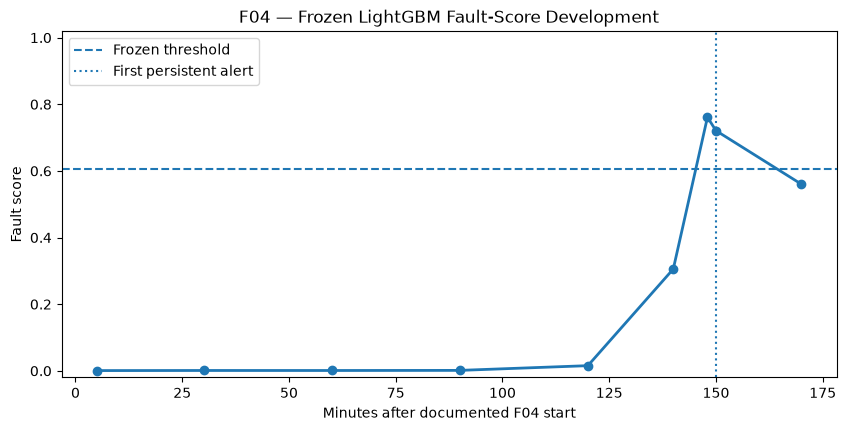

In [27]:
F04_CHECKPOINT_SCORES = pd.DataFrame({
    "minutes_after_start": [5, 30, 60, 90, 120, 140, 148, 150, 170],
    "score": [
        0.0007566147,
        0.0010537986,
        0.0010060616,
        0.0013445966,
        0.0155173555,
        0.3056436200,
        0.7610955349,
        0.7208465799,
        0.5602292280,
    ],
})

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(
    F04_CHECKPOINT_SCORES["minutes_after_start"],
    F04_CHECKPOINT_SCORES["score"],
    marker="o",
    linewidth=2,
)
ax.axhline(0.6071059894, linestyle="--", label="Frozen threshold")
ax.axvline(150, linestyle=":", label="First persistent alert")
ax.set_xlabel("Minutes after documented F04 start")
ax.set_ylabel("Fault score")
ax.set_ylim(-0.02, 1.02)
ax.set_title("F04 — Frozen LightGBM Fault-Score Development")
ax.legend()
plt.show()

The score stayed around **0.001** for much of the first 90 minutes.

Therefore F04 was not simply sitting just below threshold. A small threshold reduction would not have solved early detection.

# 21. Final Feature Importance

In [28]:
EXECUTED_GAIN_IMPORTANCE = pd.DataFrame([
    ("DV_pressure_mean", 2268249.298008675, 291),
    ("DV_pressure_max", 601669.432765617, 582),
    ("DV_pressure_min", 74667.80983130774, 223),
    ("Oil_temperature_mean", 49994.151618208736, 257),
    ("Oil_temperature_min", 37900.53951603547, 385),
    ("TP2_max", 22699.63385516312, 264),
    ("TP2_x_COMP0", 18755.150416314602, 194),
    ("H1_minus_TP3_mean", 7140.866115450859, 227),
    ("Oil_temperature_max", 5398.20879874751, 273),
    ("Motor_current_x_COMP1", 4827.802216738462, 124),
    ("H1_std", 4477.636942327023, 64),
    ("TP3_max", 4385.4237196445465, 51),
    ("H1_mean", 3162.3623928278685, 163),
    ("TP2_mean", 2493.1913804512005, 101),
    ("Reservoirs_max", 2464.0358962118626, 70),
], columns=["feature", "gain", "split"])

EXECUTED_GAIN_IMPORTANCE

,feature,gain,split
0,DV_pressure_mean,2.268249e+06,291
1,DV_pressure_max,6.016694e+05,582
2,DV_pressure_min,7.466781e+04,223
3,Oil_temperature_mean,4.999415e+04,257
4,Oil_temperature_min,3.790054e+04,385
5,TP2_max,2.269963e+04,264
6,TP2_x_COMP0,1.875515e+04,194
7,H1_minus_TP3_mean,7.140866e+03,227
8,Oil_temperature_max,5.398209e+03,273
9,Motor_current_x_COMP1,4.827802e+03,124


# 22. SHAP Explainability

SHAP was applied after model selection.

It explains feature contribution to the model score. It does **not** prove physical causation.

In [29]:
EXECUTED_SHAP_TOP = {
    "F02": [
        ("DV_pressure_mean", 11.57567, 11.56845),
        ("DV_pressure_max", 3.20305, 3.20055),
        ("H1_std", 1.83544, 1.83145),
        ("DV_pressure_min", 0.97915, 0.97528),
        ("DV_pressure_last", 0.45724, 0.45716),
        ("Oil_temperature_min", 0.31629, 0.31622),
        ("Motor_current_x_COMP1", 0.29669, 0.29581),
        ("Motor_current_max", 0.24907, 0.24879),
        ("TP3_mean", 0.23399, 0.23336),
        ("TP2_max", 0.14845, 0.14831),
    ],
    "F03": [
        ("DV_pressure_mean", 3.18436, 3.18436),
        ("TP2_max", 1.30256, -1.07048),
        ("DV_pressure_max", 1.14649, -0.40107),
        ("DV_pressure_min", 0.95289, 0.95289),
        ("Oil_temperature_min", 0.87852, 0.87852),
        ("TP3_max", 0.65468, 0.01150),
        ("Motor_current_x_COMP1", 0.51798, 0.51798),
        ("H1_std", 0.41036, 0.41031),
        ("H1_minus_TP3_mean", 0.31570, -0.16018),
        ("TP2_last", 0.30884, 0.30884),
    ],
    "F04": [
        ("DV_pressure_min", 1.44939, 1.44939),
        ("Motor_current_x_COMP1", 1.44267, 1.42792),
        ("Oil_temperature_min", 1.31396, 1.31396),
        ("H1_std", 0.62738, 0.62647),
        ("DV_pressure_max", 0.53016, -0.53016),
        ("DV_pressure_mean", 0.48550, 0.39828),
        ("Oil_temperature_mean", 0.28268, 0.28268),
        ("DV_pressure_last", 0.28149, 0.27646),
        ("TP3_minus_Reservoirs_mean", 0.26974, -0.22421),
        ("Oil_temperature_max", 0.24091, 0.24091),
    ],
}

for event, rows in EXECUTED_SHAP_TOP.items():
    print("\n", event)
    display(pd.DataFrame(
        rows,
        columns=["feature", "mean_abs_shap", "mean_signed_shap"],
    ))


 F02


,feature,mean_abs_shap,mean_signed_shap
0,DV_pressure_mean,11.57567,11.56845
1,DV_pressure_max,3.20305,3.20055
2,H1_std,1.83544,1.83145
3,DV_pressure_min,0.97915,0.97528
4,DV_pressure_last,0.45724,0.45716
5,Oil_temperature_min,0.31629,0.31622
6,Motor_current_x_COMP1,0.29669,0.29581
7,Motor_current_max,0.24907,0.24879
8,TP3_mean,0.23399,0.23336
9,TP2_max,0.14845,0.14831



 F03


,feature,mean_abs_shap,mean_signed_shap
0,DV_pressure_mean,3.18436,3.18436
1,TP2_max,1.30256,-1.07048
2,DV_pressure_max,1.14649,-0.40107
3,DV_pressure_min,0.95289,0.95289
4,Oil_temperature_min,0.87852,0.87852
5,TP3_max,0.65468,0.01150
6,Motor_current_x_COMP1,0.51798,0.51798
7,H1_std,0.41036,0.41031
8,H1_minus_TP3_mean,0.31570,-0.16018
9,TP2_last,0.30884,0.30884



 F04


,feature,mean_abs_shap,mean_signed_shap
0,DV_pressure_min,1.44939,1.44939
1,Motor_current_x_COMP1,1.44267,1.42792
2,Oil_temperature_min,1.31396,1.31396
3,H1_std,0.62738,0.62647
4,DV_pressure_max,0.53016,-0.53016
5,DV_pressure_mean,0.48550,0.39828
6,Oil_temperature_mean,0.28268,0.28268
7,DV_pressure_last,0.28149,0.27646
8,TP3_minus_Reservoirs_mean,0.26974,-0.22421
9,Oil_temperature_max,0.24091,0.24091


### Event-level interpretation

**F02:** extremely strong `DV_pressure_mean` signature.

**F03:** pressure remained important but evidence was distributed across TP2, temperature and state/current features.

**F04:** different regime, with `DV_pressure_min`, motor-current/state interaction, temperature and H1 variability among the dominant contributors.

Pressure-related information recurs across events, but the exact manifestation changes.

In [30]:
F04_SHAP_CHECKPOINTS = pd.DataFrame([
    (5, 0.0007566, "Motor_current_x_COMP1", 1.02972),
    (5, 0.0007566, "DV_pressure_mean", -0.07941),
    (5, 0.0007566, "Oil_temperature_mean", 0.13310),

    (90, 0.0013446, "Motor_current_x_COMP1", 1.07567),
    (90, 0.0013446, "DV_pressure_mean", -0.11152),
    (90, 0.0013446, "Oil_temperature_mean", 0.08011),

    (120, 0.0155174, "Motor_current_x_COMP1", 1.50064),
    (120, 0.0155174, "DV_pressure_mean", -0.14103),
    (120, 0.0155174, "Oil_temperature_mean", 0.14418),

    (140, 0.3056436, "Motor_current_x_COMP1", 1.91683),
    (140, 0.3056436, "DV_pressure_mean", 0.13856),
    (140, 0.3056436, "Oil_temperature_mean", 0.17032),

    (148, 0.7610955, "Motor_current_x_COMP1", 1.85038),
    (148, 0.7610955, "DV_pressure_mean", 0.26915),
    (148, 0.7610955, "Oil_temperature_mean", 0.32588),

    (150, 0.7208466, "Motor_current_x_COMP1", 1.78659),
    (150, 0.7208466, "DV_pressure_mean", 0.26806),
    (150, 0.7208466, "Oil_temperature_mean", 0.33117),
], columns=[
    "minutes_after_start",
    "score",
    "feature",
    "shap_value",
])

F04_SHAP_CHECKPOINTS

,minutes_after_start,score,feature,shap_value
0,5,0.000757,Motor_current_x_COMP1,1.02972
1,5,0.000757,DV_pressure_mean,-0.07941
2,5,0.000757,Oil_temperature_mean,0.13310
3,90,0.001345,Motor_current_x_COMP1,1.07567
4,90,0.001345,DV_pressure_mean,-0.11152
5,90,0.001345,Oil_temperature_mean,0.08011
6,120,0.015517,Motor_current_x_COMP1,1.50064
7,120,0.015517,DV_pressure_mean,-0.14103
8,120,0.015517,Oil_temperature_mean,0.14418
9,140,0.305644,Motor_current_x_COMP1,1.91683


Around +140 to +150 minutes:

- motor-current/state evidence strengthened;
- `DV_pressure_mean` changed from fault-opposing to fault-supporting;
- oil-temperature contribution increased.

The persistent alert appeared when several pieces of evidence aligned.

In [31]:
if RUN_SHAP_REPRODUCTION and RUN_FAULTSTATE_REPRODUCTION and master_inline is not None:
    try:
        import shap

        model, _, _ = train_final_and_evaluate_f04(master_inline)

        start, end = event_bounds("F04")
        f04 = master_inline[
            (master_inline["timestamp"] > start)
            & (master_inline["timestamp"] <= end + pd.Timedelta(minutes=1))
            & master_inline["quality__low_sample_minute"].eq(0)
            & master_inline["quality__raw_gap_over_30s"].eq(0)
            & master_inline[CURRENT_FEATURES].notna().all(axis=1)
        ].copy()

        explainer = shap.TreeExplainer(model)
        values = explainer.shap_values(
            f04[CURRENT_FEATURES],
            check_additivity=False,
        )

        if isinstance(values, list):
            values = values[-1]

        values = np.asarray(values)
        if values.ndim == 3 and values.shape[-1] == 2:
            values = values[:, :, 1]

        shap_table = pd.DataFrame({
            "feature": CURRENT_FEATURES,
            "mean_abs_shap": np.abs(values).mean(axis=0),
            "mean_signed_shap": values.mean(axis=0),
        }).sort_values("mean_abs_shap", ascending=False)

        display(shap_table.head(15))

    except Exception as exc:
        print("SHAP reproduction skipped:", exc)

# 23. Ensemble Learning Challengers

Base models:

- LightGBM Current
- XGBoost Current
- Random Forest Current
- Isolation Forest Current

Ensembles:

- LightGBM + XGBoost
- LightGBM + Isolation Forest
- LightGBM + XGBoost + Isolation Forest
- max-risk LightGBM / Isolation Forest

Scores were converted to training-normal empirical percentiles before combination so different score scales could be compared.

In [32]:
def empirical_percentile(reference_scores, scores):
    ref = np.sort(np.asarray(reference_scores, dtype=float))
    x = np.asarray(scores, dtype=float)
    return np.searchsorted(ref, x, side="right").astype(float) / len(ref)

In [33]:
EXECUTED_ENSEMBLE_RANKING = pd.DataFrame([
    ("Random Forest Current", 0.7907256202, 0.6055520198),
    ("XGBoost Current", 0.7810201601, 0.5724046928),
    ("LGBM_XGB_50_50", 0.7807866753, 0.5724255235),
    ("LightGBM Current (percentile experiment)", 0.7792100306, 0.5725039462),
    ("MAX_LGBM_IF", 0.7720414242, 0.5724492367),
    ("LGBM_XGB_IF_40_40_20", 0.5273797042, 0.0789311951),
    ("LGBM_IF_80_20", 0.5258437173, 0.0797390657),
    ("Isolation Forest Current", 0.3541713583, 0.0389219304),
], columns=[
    "candidate",
    "mean_pr_auc",
    "minimum_event_pr_auc",
])

EXECUTED_ENSEMBLE_RANKING

,candidate,mean_pr_auc,minimum_event_pr_auc
0,Random Forest Current,0.790726,0.605552
1,XGBoost Current,0.781020,0.572405
2,LGBM_XGB_50_50,0.780787,0.572426
3,LightGBM Current (percentile experiment),0.779210,0.572504
4,MAX_LGBM_IF,0.772041,0.572449
5,LGBM_XGB_IF_40_40_20,0.527380,0.078931
6,LGBM_IF_80_20,0.525844,0.079739
7,Isolation Forest Current,0.354171,0.038922


### Important metric note

The ensemble experiment used percentile-normalized scores, which create top-end ties and change PR-AUC.

Therefore the authoritative raw LightGBM development PR-AUC remains **0.9208**, not the 0.779 value in the ensemble score-space experiment.

In [34]:
EXECUTED_ENSEMBLE_OPERATIONAL = pd.DataFrame([
    ("LightGBM Current", 0.9990, "2/2", 1.0, 0.03621639295, 0.07243278590),
    ("LightGBM Current", 0.9995, "2/2", 1.0, 0.03621639295, 0.07243278590),
    ("MAX_LGBM_IF", 0.9990, "2/2", 1.0, 0.03621639295, 0.07243278590),
    ("MAX_LGBM_IF", 0.9995, "2/2", 1.0, 0.03621639295, 0.07243278590),
    ("XGBoost Current", 0.9950, "2/2", 1.0, 0.3768566705, 0.6812805551),
    ("LGBM_XGB_50_50", 0.9950, "2/2", 1.0, 0.3768566705, 0.6812805551),
    ("Random Forest Current", 0.9950, "2/2", 1.0, 0.4904034297, 0.9083740735),
], columns=[
    "candidate",
    "threshold_quantile",
    "events_detected",
    "median_delay_min",
    "mean_false_alarms_per_day",
    "worst_false_alarms_per_day",
])

EXECUTED_ENSEMBLE_OPERATIONAL

,candidate,threshold_quantile,events_detected,median_delay_min,mean_false_alarms_per_day,worst_false_alarms_per_day
0,LightGBM Current,0.9990,2/2,1.0,0.036216,0.072433
1,LightGBM Current,0.9995,2/2,1.0,0.036216,0.072433
2,MAX_LGBM_IF,0.9990,2/2,1.0,0.036216,0.072433
3,MAX_LGBM_IF,0.9995,2/2,1.0,0.036216,0.072433
4,XGBoost Current,0.9950,2/2,1.0,0.376857,0.681281
5,LGBM_XGB_50_50,0.9950,2/2,1.0,0.376857,0.681281
6,Random Forest Current,0.9950,2/2,1.0,0.490403,0.908374


No ensemble improved the selected operating point enough to justify extra complexity.

`MAX_LGBM_IF` matched LightGBM operationally but added another model and had worse ranking performance.

# 24. TinyCNN-30m Deep-Learning Challenger

Input:

\[
30\text{ minutes} \times 18\text{ channels}
\]

Architecture:

- Conv1D 18 → 32
- BatchNorm + ReLU
- Conv1D 32 → 64
- BatchNorm + ReLU
- Global Average Pooling
- Dense 64 → 32 → 1
- Dropout 0.20

Approximate parameters: **11,425**

Training used weighted BCEWithLogitsLoss, AdamW, fixed 15 epochs and no evaluation-event early stopping.

In [35]:
def deep_sequence_channels():
    return [
        "TP2_mean",
        "TP3_mean",
        "H1_mean",
        "DV_pressure_mean",
        "Reservoirs_mean",
        "Oil_temperature_mean",
        "Motor_current_mean",
        "COMP_mean",
        "DV_eletric_mean",
        "Towers_mean",
        "MPG_mean",
        "LPS_mean",
        "Pressure_switch_mean",
        "Oil_level_mean",
        "Caudal_impulses_mean",
        "COMP_MPG_mismatch_mean",
        "COMP_DV_equal_mean",
        "TP3_Reservoir_abs_diff_mean",
    ]


def make_gap_safe_sequences(master, role_df, sequence_length=30):
    channels = deep_sequence_channels()
    df = master.sort_values("timestamp").reset_index(drop=True).copy()

    role_map = role_df.set_index("timestamp")["role"].to_dict()
    timestamp_to_idx = pd.Series(df.index, index=df["timestamp"]).to_dict()

    values = df[channels].to_numpy(np.float32)
    segments = df["quality__segment_id"].to_numpy()
    low_sample = df["quality__low_sample_minute"].to_numpy()
    raw_gap = df["quality__raw_gap_over_30s"].to_numpy()
    timestamps = df["timestamp"].to_numpy()

    X, y, meta = [], [], []

    for ts, role in role_map.items():
        if ts not in timestamp_to_idx:
            continue

        end = timestamp_to_idx[ts]
        start = end - sequence_length + 1

        if start < 0:
            continue
        if segments[start] != segments[end]:
            continue
        if low_sample[start:end + 1].any():
            continue
        if raw_gap[start:end + 1].any():
            continue

        seq_ts = timestamps[start:end + 1]
        if len(seq_ts) != sequence_length:
            continue

        deltas = np.diff(seq_ts) / np.timedelta64(1, "s")
        if not np.all(deltas == 60):
            continue

        seq = values[start:end + 1]
        if not np.isfinite(seq).all():
            continue

        X.append(seq)
        y.append(int(role in ["train_failure", "evaluation_failure"]))
        meta.append({"timestamp": ts, "role": role})

    return (
        np.asarray(X, np.float32),
        np.asarray(y, np.float32),
        pd.DataFrame(meta),
    )

In [36]:
def define_tinycnn():
    import torch
    import torch.nn as nn

    class TinyCNN1D(nn.Module):
        def __init__(self, n_channels=18):
            super().__init__()

            self.encoder = nn.Sequential(
                nn.Conv1d(n_channels, 32, kernel_size=5, padding=2),
                nn.BatchNorm1d(32),
                nn.ReLU(),
                nn.Conv1d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
            )

            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.20),
                nn.Linear(32, 1),
            )

        def forward(self, x):
            return self.head(self.encoder(x)).squeeze(1)

    return TinyCNN1D

In [37]:
EXECUTED_CNN_RESULTS = {
    "model": "TinyCNN-30m",
    "parameters": 11425,
    "mean_pr_auc": 0.6344530276577458,
    "minimum_event_pr_auc": 0.5342216776828789,
    "maximum_event_pr_auc": 0.7346843776326129,
    "F02_pr_auc": 0.5342216776828789,
    "F03_pr_auc": 0.7346843776326129,
    "events_detected": "2/2",
    "best_median_detection_delay_minutes": 1.0,
    "best_practical_worst_false_alarms_per_day": 0.25351475063504436,
}

pd.Series(EXECUTED_CNN_RESULTS, name="value").to_frame()

,value
model,TinyCNN-30m
parameters,11425
mean_pr_auc,0.634453
minimum_event_pr_auc,0.534222
maximum_event_pr_auc,0.734684
F02_pr_auc,0.534222
F03_pr_auc,0.734684
events_detected,2/2
best_median_detection_delay_minutes,1.0
best_practical_worst_false_alarms_per_day,0.253515


# 25. GRU-30m Deep-Learning Challenger

Because RNN-family models are designed for sequential data, a GRU was also tested.

Architecture:

- input: 30 × 18
- one GRU layer
- hidden size: 32
- dense 32 → 16 → 1
- dropout 0.20

Approximate parameters: **5,537**

In [38]:
def define_tinygru():
    import torch
    import torch.nn as nn

    class TinyGRU(nn.Module):
        def __init__(self, input_size=18, hidden_size=32):
            super().__init__()

            self.gru = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=1,
                batch_first=True,
            )

            self.head = nn.Sequential(
                nn.Linear(hidden_size, 16),
                nn.ReLU(),
                nn.Dropout(0.20),
                nn.Linear(16, 1),
            )

        def forward(self, x):
            _, hidden = self.gru(x)
            return self.head(hidden[-1]).squeeze(1)

    return TinyGRU

## Deep-learning training transparency

For both CNN and GRU:

1. forward pass produces logits;
2. weighted `BCEWithLogitsLoss` computes error;
3. `loss.backward()` computes gradients;
4. AdamW updates parameters;
5. epoch count was fixed beforehand;
6. F02/F03 were not used for early-stopping epoch selection.

In [39]:
def pytorch_training_step_example(model, batch_x, batch_y, optimizer, criterion):
    optimizer.zero_grad(set_to_none=True)
    logits = model(batch_x)
    loss = criterion(logits, batch_y)
    loss.backward()
    optimizer.step()
    return float(loss.item())

In [40]:
EXECUTED_GRU_RESULTS = {
    "model": "GRU-30m",
    "parameters": 5537,
    "mean_pr_auc": 0.5207577449132516,
    "minimum_event_pr_auc": 0.08865156476219611,
    "maximum_event_pr_auc": 0.9528639250643071,
    "F02_pr_auc": 0.08865156476219611,
    "F03_pr_auc": 0.9528639250643071,
    "events_detected": "2/2",
    "best_median_detection_delay_minutes": 2.5,
    "best_worst_false_alarms_per_day": 1.1589245743316314,
}

pd.Series(EXECUTED_GRU_RESULTS, name="value").to_frame()

,value
model,GRU-30m
parameters,5537
mean_pr_auc,0.520758
minimum_event_pr_auc,0.088652
maximum_event_pr_auc,0.952864
F02_pr_auc,0.088652
F03_pr_auc,0.952864
events_detected,2/2
best_median_detection_delay_minutes,2.5
best_worst_false_alarms_per_day,1.158925


The GRU learned F03 extremely well but transferred poorly to F02.

The issue is not that recurrent models are inappropriate. The limiting factor is the extremely small number of **independent fault episodes**.

# 26. Literature Check and ASPIRE-Inspired Raw-Sequence Transformer

After the frozen F04 result exposed a 150-minute confirmation delay, related work on the **same MetroPT-3 dataset** was reviewed.

A particularly relevant 2026 study, **ASPIRE**, uses high-frequency sequence modelling, a two-hour Warning class and additional anomaly/context decision agents. This changed the interpretation of our earlier pre-fault result:

> We should **not** say that MetroPT-3 cannot contain useful pre-event information.

The defensible statement is:

> **Our one-minute/event-wise formulations did not extract a stable transferable pre-fault warning signal. A different high-frequency sequence formulation has been reported to perform strongly under a different evaluation/decision framework.**

To test whether one-minute aggregation had discarded useful temporal information, AirGuard-LK implemented one **ASPIRE-inspired Transformer challenger**. It is not claimed as an exact ASPIRE reproduction.


In [41]:
# ASPIRE-inspired raw-sequence challenger configuration.
ASPIRE_INSPIRED_CONFIG = {
    "resolution": "raw ~10-second observations",
    "sensors": [
        "TP2", "TP3", "H1", "DV_pressure", "Reservoirs",
        "Oil_temperature", "Motor_current", "COMP",
        "DV_eletric", "Towers", "MPG", "LPS",
    ],
    "window_samples": 100,
    "approx_window_minutes": 16.67,
    "classes": ["Normal", "Warning", "Fault"],
    "warning_horizon_hours": 2,
    "transformer_blocks": 2,
    "d_model": 64,
    "attention_heads": 4,
    "feedforward_dim": 128,
    "dropout": 0.2,
    "seed": 42,
    "development_event": "F03",
    "retrospective_event": "F04",
}
pd.Series(ASPIRE_INSPIRED_CONFIG, name="value").to_frame()


,value
resolution,raw ~10-second observations
sensors,"[TP2, TP3, H1, DV_pressure, Reservoirs, Oil_te..."
window_samples,100
approx_window_minutes,16.67
classes,"[Normal, Warning, Fault]"
warning_horizon_hours,2
transformer_blocks,2
d_model,64
attention_heads,4
feedforward_dim,128


In [42]:
def build_three_class_point_labels(timestamps, events=EVENTS, warning_hours=2):
    """0=Normal, 1=Warning, 2=Fault; Fault overrides Warning."""
    ts = pd.to_datetime(timestamps)
    y = np.zeros(len(ts), dtype=np.int8)

    for _, event in events.iterrows():
        start = event["start_time"]
        end = event["end_time"]
        warning_start = start - pd.Timedelta(hours=warning_hours)

        warning = (ts >= warning_start) & (ts < start)
        fault = (ts >= start) & (ts <= end)

        y[np.asarray(warning)] = 1
        y[np.asarray(fault)] = 2

    return y


def any_point_window_labels(point_labels, window=100):
    """Fault > Warning > Normal, therefore rolling maximum implements override."""
    return (
        pd.Series(point_labels)
        .rolling(window=window, min_periods=window)
        .max()
        .fillna(-1)
        .astype(np.int8)
        .to_numpy()
    )


# Architecture definition remains visible without requiring PyTorch at import time.
def define_aspire_inspired_transformer(n_features=12, window=100):
    import torch
    from torch import nn

    class TransformerClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            d_model = 64
            self.input_projection = nn.Linear(n_features, d_model)
            self.positional = nn.Parameter(torch.zeros(1, window, d_model))
            nn.init.normal_(self.positional, mean=0.0, std=0.02)

            layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=4,
                dim_feedforward=128,
                dropout=0.2,
                batch_first=True,
                activation="relu",
                norm_first=True,
            )
            self.encoder = nn.TransformerEncoder(layer, num_layers=2)
            self.norm = nn.LayerNorm(d_model)
            self.head = nn.Linear(d_model, 3)

        def forward(self, x):
            z = self.input_projection(x)
            z = z + self.positional[:, :z.shape[1]]
            z = self.encoder(z)
            z = self.norm(z).mean(dim=1)
            return self.head(z)

    return TransformerClassifier()


In [43]:
EXECUTED_TRANSFORMER_20EP = {
    "epochs": 20,
    "device": "CUDA",
    "trainable_parameters": 74499,
    "F03_warning_precision": 0.09975734699379887,
    "F03_warning_recall": 0.509641873278237,
    "F03_warning_f1": 0.1668545659526494,
    "F03_warning_average_precision": 0.09878143475629551,
    "F03_first_persistent_warning_lead_min": 3.4,
    "F03_warning_false_episodes_per_day": 1.5621986499517841,
    "F04_warning_precision": 0.0,
    "F04_warning_recall": 0.0,
    "F04_warning_f1": 0.0,
    "F04_warning_average_precision": 0.06121024389828528,
    "F04_persistent_prefault_warning": False,
    "F04_fault_precision": 0.8149141630901288,
    "F04_fault_recall": 0.9980289093298291,
    "F04_fault_f1": 0.8972238629651507,
    "F04_fault_average_precision": 0.9853293227362073,
    "F04_fault_roc_auc": 0.9979251881067954,
}
pd.Series(EXECUTED_TRANSFORMER_20EP, name="value").to_frame()


,value
epochs,20
device,CUDA
trainable_parameters,74499
F03_warning_precision,0.099757
F03_warning_recall,0.509642
F03_warning_f1,0.166855
F03_warning_average_precision,0.098781
F03_first_persistent_warning_lead_min,3.4
F03_warning_false_episodes_per_day,1.562199
F04_warning_precision,0.0


### Transformer interpretation

The raw-sequence Transformer learned the **active fault state** very strongly, especially on F04, but did not generate a transferable F04 pre-fault Warning.

Therefore:

- the original +150-minute LightGBM issue was **not simply caused by using a non-neural model**;
- high-frequency sequence information contains strong fault-state information;
- under our implementation, it did **not** solve robust early warning;
- the result does not contradict ASPIRE because our challenger is not an exact reproduction of its full agentic/anomaly/context decision system.

This motivated a different question: instead of learning *what a warning looks like*, can we learn *what normal behaviour looks like* and detect departures?


### Comparison with ASPIRE must be interpreted carefully

ASPIRE reports strong Warning-class performance under its own high-frequency sequence and decision-agent framework. AirGuard-LK's experiment intentionally tested only a simplified Transformer component and additionally reports first persistent warning timing.

Therefore the notebook does **not** compare ASPIRE's published Warning F1 directly with AirGuard-LK's event lead-time metrics as if they were the same endpoint.


# 27. Normal-Only Early-Watch Anomaly Detection

The next model family changes the learning objective.

Supervised classifier:

\[
P(	ext{known fault/warning pattern}\mid X_t)
\]

Normal-only anomaly model:

\[
	ext{departure from learned normal behaviour}
\]

This is attractive when only four independent fault events exist but a much larger amount of normal operation is available.

### Fixed normal-only protocol

- causal right-closed **5-minute bins**;
- analogue channels: mean, standard deviation, minimum, maximum, last;
- digital channels: active ratio, last state, transitions;
- **59 features/bin**;
- **12 consecutive bins = 60 minutes**;
- flattened **708-feature** window;
- model fit: **1–21 February only**;
- calibration: **22–29 February only**;
- evaluation: **March–September**;
- Isolation Forest: **300 trees**;
- robust calibration using median/MAD;
- causal EWMA, \(lpha=0.2\);
- threshold derived from February calibration only;
- persistence, episode merging and cooldown applied causally.

No F01–F04 failure labels are used to fit the Isolation Forest or derive its normal calibration threshold.


In [44]:
EARLY_WATCH_FEATURE_CONFIG = {
    "bin_minutes": 5,
    "analog_features_per_signal": ["mean", "std", "min", "max", "last"],
    "digital_features_per_signal": ["active_ratio", "last", "transitions"],
    "features_per_bin": 59,
    "window_bins": 12,
    "window_minutes": 60,
    "flattened_features": 708,
    "fit_period": "2020-02-01 to 2020-02-21",
    "calibration_period": "2020-02-22 to 2020-02-29",
    "evaluation_period": "2020-03-01 onward",
    "iforest_trees": 300,
    "ewma_alpha": 0.2,
    "episode_merge_minutes": 30,
    "cooldown_hours": 6,
    "strict_early_definition": "new episode begins 24h to 2h before event",
}
pd.Series(EARLY_WATCH_FEATURE_CONFIG, name="value").to_frame()


,value
bin_minutes,5
analog_features_per_signal,"[mean, std, min, max, last]"
digital_features_per_signal,"[active_ratio, last, transitions]"
features_per_bin,59
window_bins,12
window_minutes,60
flattened_features,708
fit_period,2020-02-01 to 2020-02-21
calibration_period,2020-02-22 to 2020-02-29
evaluation_period,2020-03-01 onward


In [45]:
def build_earlywatch_bin_features(raw_df):
    """Core causal 5-minute feature construction used by the anomaly family."""
    df = raw_df.copy().sort_values("timestamp")
    df["bin_end"] = df["timestamp"].dt.ceil("5min")

    grouped = df.groupby("bin_end", sort=False)
    transition_cols = []
    for col in DIGITAL:
        name = f"{col}__transition"
        df[name] = grouped[col].diff().fillna(0).ne(0).astype(np.int8)
        transition_cols.append(name)

    g = df.groupby("bin_end", sort=True)

    analog = g[ANALOG].agg(["mean", "std", "min", "max", "last"])
    analog.columns = [f"{c}_{s}_5m" for c, s in analog.columns]

    digital_ratio = g[DIGITAL].mean()
    digital_ratio.columns = [f"{c}_active_ratio_5m" for c in DIGITAL]

    digital_last = g[DIGITAL].last()
    digital_last.columns = [f"{c}_last_5m" for c in DIGITAL]

    transitions = g[transition_cols].sum()
    transitions.columns = [
        c.replace("__transition", "_transitions_5m")
        for c in transitions.columns
    ]

    quality = pd.DataFrame(index=analog.index)
    quality["sample_count"] = g.size()
    quality["coverage_fraction"] = quality["sample_count"] / 30.0

    out = pd.concat(
        [analog, digital_ratio, digital_last, transitions, quality],
        axis=1
    ).reset_index()

    model_cols = [
        c for c in out.columns
        if c not in {"bin_end", "sample_count", "coverage_fraction"}
    ]
    out["bin_valid"] = (
        out["coverage_fraction"].ge(0.80)
        & out[model_cols].notna().all(axis=1)
    )

    assert len(model_cols) == 59
    return out, model_cols


def robust_z(reference_scores, scores):
    med = float(np.median(reference_scores))
    mad = float(np.median(np.abs(reference_scores - med)))
    scale = 1.4826 * mad
    return (np.asarray(scores) - med) / scale


In [46]:
def build_consecutive_60min_windows(bin_df, feature_cols):
    """Return only 12-bin windows with exact 5-minute continuity."""
    valid = (
        bin_df.loc[bin_df["bin_valid"]]
        .sort_values("bin_end")
        .reset_index(drop=True)
    )

    delta_s = valid["bin_end"].diff().dt.total_seconds()
    new_segment = valid.index.to_series().eq(0) | delta_s.ne(300)

    valid["segment_id"] = new_segment.cumsum()
    valid["segment_pos"] = valid.groupby("segment_id").cumcount() + 1

    ends = valid.index[valid["segment_pos"] >= 12].to_numpy()
    values = valid[feature_cols].to_numpy(dtype=np.float32)

    X = np.empty((len(ends), 12 * len(feature_cols)), dtype=np.float32)
    t = []

    for i, end in enumerate(ends):
        start = end - 11
        X[i] = values[start:end + 1].reshape(-1)
        t.append(valid.at[end, "bin_end"])

    return X, pd.DatetimeIndex(t, name="timestamp")


def fit_normal_only_iforest(X_fit):
    return IsolationForest(
        n_estimators=300,
        max_samples="auto",
        max_features=1.0,
        contamination="auto",
        bootstrap=False,
        random_state=SEED,
        n_jobs=-1,
    ).fit(X_fit)


def causal_segmented_ewma(timestamps, values, alpha=0.2):
    """Causal EWMA that resets when 5-minute continuity breaks."""
    values = np.asarray(values, dtype=float)
    out = np.empty(len(values), dtype=float)

    prev_t = None
    prev_score = None

    for i, (t, value) in enumerate(zip(timestamps, values)):
        reset = (
            prev_t is None
            or (pd.Timestamp(t) - pd.Timestamp(prev_t)).total_seconds() != 300
        )

        out[i] = (
            float(value)
            if reset
            else alpha * float(value) + (1 - alpha) * prev_score
        )

        prev_t = t
        prev_score = out[i]

    return out


# 28. Global Isolation Forest Early-Watch Result

A first global normal-only Isolation Forest showed that F04 contains abnormal behaviour much earlier than the supervised LightGBM recognizes as a known fault.

However, this layer was deliberately treated as **EARLY WATCH**, not a confirmed leak warning, because its nuisance burden was high.

A six-point nuisance sensitivity was predeclared over:

- calibration quantile: `0.995`, `0.999`, `0.9995`;
- persistence: `3-of-4`, `4-of-4`.

Using F01–F03 only, the selected global operating point was `q=0.9995`, `3-of-4`.


In [47]:
GLOBAL_IF_SELECTED = pd.DataFrame([
    {"Event": "F01", "Strict early lead (min)": 825},
    {"Event": "F02", "Strict early lead (min)": 175},
    {"Event": "F03", "Strict early lead (min)": 1140},
    {"Event": "F04", "Strict early lead (min)": 945},
])

GLOBAL_IF_SUMMARY = {
    "selected_quantile": 0.9995,
    "persistence": "3-of-4",
    "development_strict_early": "3/3",
    "F04_strict_early_lead_minutes": 945,
    "F04_strict_early_lead_hours": 15.75,
    "development_false_alert_episodes_per_day": 1.052288,
    "development_policy_time_in_alert_pct": 29.700017,
    "all_false_alert_episodes_per_day": 1.051744,
    "all_policy_time_in_alert_pct": 34.844471,
}

display(GLOBAL_IF_SELECTED)
pd.Series(GLOBAL_IF_SUMMARY, name="value").to_frame()


,Event,Strict early lead (min)
0,F01,825
1,F02,175
2,F03,1140
3,F04,945


,value
selected_quantile,0.9995
persistence,3-of-4
development_strict_early,3/3
F04_strict_early_lead_minutes,945
F04_strict_early_lead_hours,15.75
development_false_alert_episodes_per_day,1.052288
development_policy_time_in_alert_pct,29.700017
all_false_alert_episodes_per_day,1.051744
all_policy_time_in_alert_pct,34.844471


### Why the 15 h 45 min F04 signal is not called a prediction

The anomaly layer asks whether behaviour is unusual relative to February normal operation. It does not prove that the eventual cause is a leak.

Furthermore, the selected global detector spent about **29.7% of development time in policy alert**. Therefore:

> **F04 -945 min is evidence of early abnormality awareness, not evidence that AirGuard can reliably predict every leak 15.75 hours in advance.**

This distinction is maintained throughout the submission.


In [48]:
GLOBAL_IF_NUISANCE_SENSITIVITY = pd.DataFrame([
    {"q": 0.9950, "persistence": "3-of-4", "dev early": "3/3", "all early": "4/4",
     "all FA/day": 1.096184, "all alert time %": 38.715533,
     "dev FA/day": 1.154452, "dev alert time %": 32.582537},
    {"q": 0.9950, "persistence": "4-of-4", "dev early": "3/3", "all early": "4/4",
     "all FA/day": 1.103590, "all alert time %": 37.057207,
     "dev FA/day": 1.154452, "dev alert time %": 31.788168},
    {"q": 0.9990, "persistence": "3-of-4", "dev early": "3/3", "all early": "4/4",
     "all FA/day": 1.096184, "all alert time %": 35.114317,
     "dev FA/day": 1.113586, "dev alert time %": 29.964806},
    {"q": 0.9990, "persistence": "4-of-4", "dev early": "3/3", "all early": "4/4",
     "all FA/day": 1.059150, "all alert time %": 35.553429,
     "dev FA/day": 1.062504, "dev alert time %": 32.431708},
    {"q": 0.9995, "persistence": "3-of-4", "dev early": "3/3", "all early": "4/4",
     "all FA/day": 1.051744, "all alert time %": 34.844471,
     "dev FA/day": 1.052288, "dev alert time %": 29.700017},
    {"q": 0.9995, "persistence": "4-of-4", "dev early": "3/3", "all early": "4/4",
     "all FA/day": 1.066557, "all alert time %": 34.334216,
     "dev FA/day": 1.062504, "dev alert time %": 31.137925},
])

GLOBAL_IF_NUISANCE_SENSITIVITY


,q,persistence,dev early,all early,all FA/day,all alert time %,dev FA/day,dev alert time %
0,0.9950,3-of-4,3/3,4/4,1.096184,38.715533,1.154452,32.582537
1,0.9950,4-of-4,3/3,4/4,1.103590,37.057207,1.154452,31.788168
2,0.9990,3-of-4,3/3,4/4,1.096184,35.114317,1.113586,29.964806
3,0.9990,4-of-4,3/3,4/4,1.059150,35.553429,1.062504,32.431708
4,0.9995,3-of-4,3/3,4/4,1.051744,34.844471,1.052288,29.700017
5,0.9995,4-of-4,3/3,4/4,1.066557,34.334216,1.062504,31.137925


# 29. State-Conditioned Normal Modelling

EDA showed that analogue sensor distributions depend strongly on compressor operating state. A single global normal model can therefore treat legitimate state changes as anomalies.

A state-conditioned challenger used the current digital combination:

`(COMP_last, MPG_last, DV_eletric_last)`

as an empirical operating regime. No physical ON/OFF semantics were assigned.

Only two regimes had sufficient February support for dedicated models:

- `C0_M0_D1`
- `C1_M1_D0`

Other/unseen combinations used fallback behaviour.

The state-conditioned model preserved the F04 early-watch timestamp while reducing total alert occupancy.


In [49]:
STATE_IF_RESULTS = pd.DataFrame([
    {"Event": "F01", "Strict early lead (min)": 815},
    {"Event": "F02", "Strict early lead (min)": 1045},
    {"Event": "F03", "Strict early lead (min)": 1080},
    {"Event": "F04", "Strict early lead (min)": 945},
])

STATE_IF_SUMMARY = {
    "development_strict_early": "3/3",
    "F04_strict_early_lead_minutes": 945,
    "development_false_alert_episodes_per_day": 2.237389,
    "development_policy_time_in_alert_pct": 14.231607,
}

display(STATE_IF_RESULTS)
pd.Series(STATE_IF_SUMMARY, name="value").to_frame()


,Event,Strict early lead (min)
0,F01,815
1,F02,1045
2,F03,1080
3,F04,945


,value
development_strict_early,3/3
F04_strict_early_lead_minutes,945
development_false_alert_episodes_per_day,2.237389
development_policy_time_in_alert_pct,14.231607


In [50]:
def regime_key_from_current_bin(row):
    """Empirical state key; no physical ON/OFF semantics are assumed."""
    c = int(round(float(row["COMP_last_5m"])))
    m = int(round(float(row["MPG_last_5m"])))
    d = int(round(float(row["DV_eletric_last_5m"])))
    return f"C{c}_M{m}_D{d}"


def state_reset_ewma(timestamps, regimes, values, alpha=0.2):
    out = np.empty(len(values), dtype=float)
    prev_t = None
    prev_regime = None
    prev_score = None

    for i, (t, regime, value) in enumerate(zip(timestamps, regimes, values)):
        reset = (
            prev_t is None
            or (pd.Timestamp(t) - pd.Timestamp(prev_t)).total_seconds() != 300
            or regime != prev_regime
        )

        out[i] = (
            float(value)
            if reset
            else alpha * float(value) + (1 - alpha) * prev_score
        )

        prev_t = t
        prev_regime = regime
        prev_score = out[i]

    return out


# Dedicated regime criterion used in the executed challenger:
REGIME_MIN_FIT_WINDOWS = 250
REGIME_MIN_CAL_WINDOWS = 50


# 30. Fixed Consensus Early Watch

Because the global and state-conditioned detectors both identified the same early F04 anomaly timestamp, a fixed consensus was tested without retraining:

\[
	ext{Consensus}_t =
	ext{GlobalPersistent}_t
\land
	ext{StatePersistent}_t
\]

This is an AND rule: both anomaly views must agree.

It preserved the F04 early-watch signal and slightly reduced occupancy relative to the state-conditioned detector, but it did not sufficiently reduce false episode frequency.


In [51]:
CONSENSUS_RESULTS = pd.DataFrame([
    {"Event": "F01", "Strict early lead (min)": 815},
    {"Event": "F02", "Strict early lead (min)": 1045},
    {"Event": "F03", "Strict early lead (min)": 1080},
    {"Event": "F04", "Strict early lead (min)": 945},
])

CONSENSUS_SUMMARY = {
    "development_strict_early": "3/3",
    "F04_early_watch_lead_minutes": 945,
    "development_false_alert_episodes_per_day": 2.196524,
    "development_policy_time_in_alert_pct": 13.859561,
}

display(CONSENSUS_RESULTS)
pd.Series(CONSENSUS_SUMMARY, name="value").to_frame()


,Event,Strict early lead (min)
0,F01,815
1,F02,1045
2,F03,1080
3,F04,945


,value
development_strict_early,3/3
F04_early_watch_lead_minutes,945
development_false_alert_episodes_per_day,2.196524
development_policy_time_in_alert_pct,13.859561


In [52]:
def fixed_and_consensus(global_persistent, state_persistent):
    """No retraining or threshold change: both anomaly views must agree."""
    return (
        np.asarray(global_persistent, dtype=bool)
        & np.asarray(state_persistent, dtype=bool)
    )


# 31. Duration-Based Escalation: EARLY WATCH → WARNING

The consensus detector was still too sensitive to treat every anomaly episode as an actionable maintenance warning.

A final **operational escalation analysis** therefore required the consensus anomaly condition to remain continuously active before escalating:

- 30 minutes;
- 60 minutes;
- 120 minutes.

No model was retrained and no anomaly threshold was changed.

The duration was selected using **F01–F03 only**:

1. retain candidates with at least 2/3 strict-new-early development warnings if possible;
2. maximize development strict-new-early detections;
3. minimize false warning episodes/day;
4. minimize Warning occupancy;
5. prefer the longer duration only on a tie.

This selected **30 minutes**.


In [53]:
DURATION_SUMMARY = pd.DataFrame([
    {
        "Sustained duration (min)": 30,
        "Development strict early": "3/3",
        "Development false warnings/day": 1.838950,
        "Development WARNING time (%)": 8.215184,
        "F04 outcome": "+40 min after onset",
    },
    {
        "Sustained duration (min)": 60,
        "Development strict early": "1/3",
        "Development false warnings/day": 0.837744,
        "Development WARNING time (%)": 6.341545,
        "F04 outcome": "+70 min after onset",
    },
    {
        "Sustained duration (min)": 120,
        "Development strict early": "1/3",
        "Development false warnings/day": 0.163462,
        "Development WARNING time (%)": 5.627619,
        "F04 outcome": "+130 min after onset",
    },
])

DURATION_SUMMARY


,Sustained duration (min),Development strict early,Development false warnings/day,Development WARNING time (%),F04 outcome
0,30,3/3,1.838950,8.215184,+40 min after onset
1,60,1/3,0.837744,6.341545,+70 min after onset
2,120,1/3,0.163462,5.627619,+130 min after onset


In [54]:
def sustained_warning_flags(timestamps, consensus_persistent, required_minutes):
    """Escalate Watch -> Warning only after continuous consensus abnormality."""
    required_steps = int(required_minutes / 5)
    out = np.zeros(len(consensus_persistent), dtype=bool)

    streak = 0
    prev_t = None

    for i, (t, flag) in enumerate(zip(timestamps, consensus_persistent)):
        contiguous = (
            prev_t is not None
            and (pd.Timestamp(t) - pd.Timestamp(prev_t)).total_seconds() == 300
        )

        if not contiguous:
            streak = 0

        streak = streak + 1 if bool(flag) else 0
        out[i] = streak >= required_steps
        prev_t = t

    return out


DURATION_CANDIDATES_MIN = [30, 60, 120]


In [55]:
SELECTED_WARNING_EVENTS = pd.DataFrame([
    {"Event": "F01", "Warning relative to fault start (min)": -735, "Interpretation": "735 min early"},
    {"Event": "F02", "Warning relative to fault start (min)": -1020, "Interpretation": "1020 min early"},
    {"Event": "F03", "Warning relative to fault start (min)": -1055, "Interpretation": "1055 min early"},
    {"Event": "F04", "Warning relative to fault start (min)": 40, "Interpretation": "40 min after onset"},
])

F04_LIGHTGBM_DELAY = 150
F04_ESCALATED_WARNING_DELAY = 40
F04_RESPONSE_IMPROVEMENT = F04_LIGHTGBM_DELAY - F04_ESCALATED_WARNING_DELAY

display(SELECTED_WARNING_EVENTS)
print("F04 response improvement relative to frozen LightGBM:",
      F04_RESPONSE_IMPROVEMENT, "minutes")


,Event,Warning relative to fault start (min),Interpretation
0,F01,-735,735 min early
1,F02,-1020,1020 min early
2,F03,-1055,1055 min early
3,F04,40,40 min after onset


F04 response improvement relative to frozen LightGBM: 110 minutes


### Why F04 can have an EARLY WATCH at -945 min but a WARNING at +40 min

These are deliberately different operational states.

- **EARLY WATCH** requires anomaly consensus and is designed to be sensitive.
- **WARNING** requires that consensus to remain continuously abnormal for the selected 30-minute duration.

Before F04, unusual behaviour appeared much earlier, but it did **not** remain continuously elevated for the full escalation duration. The system therefore did not escalate that early episode into an actionable Warning.

This prevents the notebook from presenting a sensitive anomaly flag as if it were a high-confidence fault prediction.


In [56]:
DURATION_EVENT_RESULTS = pd.DataFrame([
    {"duration_min": 30, "event": "F01", "status": "STRICT_EARLY", "relative_min": -735},
    {"duration_min": 30, "event": "F02", "status": "STRICT_EARLY", "relative_min": -1020},
    {"duration_min": 30, "event": "F03", "status": "STRICT_EARLY", "relative_min": -1055},
    {"duration_min": 30, "event": "F04", "status": "LATE", "relative_min": 40},
    {"duration_min": 60, "event": "F01", "status": "LATE", "relative_min": -95},
    {"duration_min": 60, "event": "F02", "status": "STRICT_EARLY", "relative_min": -870},
    {"duration_min": 60, "event": "F03", "status": "LATE", "relative_min": 85},
    {"duration_min": 60, "event": "F04", "status": "LATE", "relative_min": 70},
    {"duration_min": 120, "event": "F01", "status": "LATE", "relative_min": 215},
    {"duration_min": 120, "event": "F02", "status": "STRICT_EARLY", "relative_min": -810},
    {"duration_min": 120, "event": "F03", "status": "LATE", "relative_min": 145},
    {"duration_min": 120, "event": "F04", "status": "LATE", "relative_min": 130},
])

DURATION_EVENT_RESULTS


,duration_min,event,status,relative_min
0,30,F01,STRICT_EARLY,-735
1,30,F02,STRICT_EARLY,-1020
2,30,F03,STRICT_EARLY,-1055
3,30,F04,LATE,40
4,60,F01,LATE,-95
5,60,F02,STRICT_EARLY,-870
6,60,F03,LATE,85
7,60,F04,LATE,70
8,120,F01,LATE,215
9,120,F02,STRICT_EARLY,-810


# 32. Final Multi-Stage AirGuard-LK Architecture

```text
                         SENSOR STREAM
                              |
                 +------------+------------+
                 |                         |
                 v                         v
        Global normal-only IF     State-conditioned IF
                 |                         |
                 +------------+------------+
                              |
                       AND CONSENSUS
                              |
                              v
                         EARLY WATCH
                  "unusual behaviour"
                              |
                    sustained for 30 min
                              |
                              v
                            WARNING
                   "engineer should inspect"
                              |
                              v
                    State-aware LightGBM
                              |
                              v
                     FAULT CONFIRMATION
                  "known fault-like pattern"
                              |
                              v
                       HUMAN DECISION
```

### Operational interpretation

**EARLY WATCH**
- sensitive novelty awareness;
- may occur long before a documented event;
- not a confirmed leak prediction;
- can increase logging/inspection priority.

**WARNING**
- sustained abnormality;
- selected duration = 30 minutes from F01–F03 development;
- F04 retrospective response = **+40 minutes**;
- 110 minutes faster than frozen LightGBM confirmation.

**FAULT CONFIRMATION**
- 71-feature state-aware LightGBM;
- low nuisance burden in the primary development benchmark;
- interpretable with SHAP;
- confirms resemblance to known fault behaviour.

No stage automatically shuts down industrial equipment.


# 33. Primary Evidence vs Post-Hoc System Refinement

The submission deliberately separates two evidence tiers.

### Tier A — Primary frozen result

Frozen before final F04 evaluation:

- LightGBM Current;
- 71 features;
- `q=0.9995`;
- 3-minute persistence;
- development selection on F02/F03;
- F04 persistent confirmation at **+150 minutes** with zero primary false-alarm episodes.

This remains the cleanest final-holdout evidence.

### Tier B — Post-hoc system refinement

After the F04 limitation was known:

- ASPIRE-inspired Transformer;
- global normal-only Isolation Forest;
- nuisance sensitivity;
- state-conditioned Isolation Forest;
- fixed consensus;
- duration-based escalation.

Where possible, operating parameters were selected on F01–F03 and then applied unchanged to F04. However, because the **choice to investigate these model families was itself motivated by the known F04 failure**, their F04 results are reported as **retrospective/post-hoc**, not as pristine unseen-holdout results.

This distinction is central to the scientific integrity of AirGuard-LK.


# 34. Comparative Model and System-Layer Summary

AirGuard-LK does not treat one model as universally best for every objective. Different models solve different industrial sub-problems.

### Fault-state model selection

LightGBM Current remains the selected **fault-confirmation model** because it gave the strongest event-wise development trade-off.


In [57]:
FAULT_MODEL_COMPARISON = pd.DataFrame([
    {
        "Model": "LightGBM Current",
        "Mean development PR-AUC": 0.920766,
        "Minimum-event PR-AUC": 0.855593,
        "Events detected": "2/2",
        "Median delay (min)": 1.0,
        "Role / decision": "SELECTED fault confirmation",
    },
    {
        "Model": "TinyCNN-30m",
        "Mean development PR-AUC": 0.634453,
        "Minimum-event PR-AUC": 0.534222,
        "Events detected": "2/2",
        "Median delay (min)": 1.0,
        "Role / decision": "Rejected",
    },
    {
        "Model": "GRU-30m",
        "Mean development PR-AUC": 0.520758,
        "Minimum-event PR-AUC": 0.088652,
        "Events detected": "2/2",
        "Median delay (min)": 2.5,
        "Role / decision": "Rejected",
    },
])

SYSTEM_LAYER_SUMMARY = pd.DataFrame([
    {
        "Layer": "Early Watch",
        "Mechanism": "Global IF AND state-conditioned IF",
        "Development result": "3/3 strict early anomaly episodes",
        "F04 retrospective result": "-945 min",
        "Interpretation": "Sensitive novelty awareness",
    },
    {
        "Layer": "Warning",
        "Mechanism": "Consensus sustained for 30 min",
        "Development result": "3/3 strict early warnings",
        "F04 retrospective result": "+40 min",
        "Interpretation": "Human inspection trigger",
    },
    {
        "Layer": "Fault Confirmation",
        "Mechanism": "71-feature LightGBM + 3-min persistence",
        "Development result": "2/2; median delay 1 min",
        "F04 retrospective result": "+150 min",
        "Interpretation": "Known fault-like confirmation",
    },
])

display(FAULT_MODEL_COMPARISON)
display(SYSTEM_LAYER_SUMMARY)


,Model,Mean development PR-AUC,Minimum-event PR-AUC,Events detected,Median delay (min),Role / decision
0,LightGBM Current,0.920766,0.855593,2/2,1.0,SELECTED fault confirmation
1,TinyCNN-30m,0.634453,0.534222,2/2,1.0,Rejected
2,GRU-30m,0.520758,0.088652,2/2,2.5,Rejected


,Layer,Mechanism,Development result,F04 retrospective result,Interpretation
0,Early Watch,Global IF AND state-conditioned IF,3/3 strict early anomaly episodes,-945 min,Sensitive novelty awareness
1,Warning,Consensus sustained for 30 min,3/3 strict early warnings,+40 min,Human inspection trigger
2,Fault Confirmation,71-feature LightGBM + 3-min persistence,2/2; median delay 1 min,+150 min,Known fault-like confirmation


> **Model complexity was not treated as a proxy for intelligence.**

The CNN, GRU and Transformer were useful challengers, but they did not replace LightGBM as the higher-specificity fault-confirmation model. Normal-only anomaly detection solved a different problem: identifying behaviour that is unusual even when it does not yet resemble earlier labelled faults.

The final architecture therefore uses **specialized layers rather than one universal classifier**.


# 35. Why Accuracy and ROC-AUC Alone Are Not Enough

Industrial fault datasets are strongly imbalanced and temporally correlated.

A model can achieve high accuracy by predicting the majority normal class. ROC-AUC can also remain high even when the precision of rare alerts is poor.

For AirGuard-LK, the most important evaluation quantities are therefore:

- **PR-AUC / Average Precision** for rare fault ranking;
- **event detection** across independent physical fault episodes;
- **first persistent alert timing** relative to event start;
- **false-alarm episodes/day**;
- **time spent in Watch/Warning**;
- **per-event transfer**, not random-row accuracy.

The final escalation analysis demonstrates why operational metrics matter: increasing sustained duration reduced nuisance, but also removed early detection on several events.


# 36. Proposed Industrial Deployment

```text
Existing compressor sensors
          |
          v
PLC / industrial gateway
          |
          +-------------------------------+
          |                               |
          v                               v
5-min causal anomaly features       1-min 71 state-aware features
          |                               |
          v                               v
Global + state-normal models        LightGBM fault classifier
          |                               |
          v                               |
Consensus Early Watch                |
          |                               |
30-min sustained abnormality         |
          |                               |
          v                               |
WARNING ------------------------------+
          |
          v
Maintenance dashboard / notification
          |
          v
Engineer inspection and decision
```

### Recommended operational actions

**EARLY WATCH**
- increase monitoring attention;
- log the period for inspection;
- avoid automatic shutdown.

**WARNING**
- prompt maintenance personnel to inspect compressor/receiver/discharge lines, valves and pneumatic circuit;
- check pressure instability, unusual current/state behaviour and temperature.

**FAULT CONFIRMATION**
- raise priority because behaviour resembles documented historical fault conditions.

The system remains **human-in-the-loop**. It should not automatically shut down industrial equipment in an initial deployment.


# 37. Customer Benefit and Operational Interpretation

The difficult F04 event lasted about **270 minutes**.

Frozen LightGBM confirmation occurred:

\[
+150	ext{ min}
\]

The development-selected sustained Warning occurred retrospectively at:

\[
+40	ext{ min}
\]

Therefore the refined warning logic responded:

\[
150-40=oxed{110	ext{ minutes faster}}
\]

At +40 minutes, approximately:

\[
270-40=oxed{230	ext{ minutes}}
\]

of the documented F04 event window still remained.

This does **not** prove that intervention would save exactly 230 minutes of energy loss or damage. It does show that the customer could receive an actionable investigation prompt much earlier during the event.

The earlier -945 minute anomaly signal is kept as **Early Watch** because its nuisance burden is too high to interpret as confirmed leak prediction.


# 38. Sri Lankan Relevance

AirGuard-LK is intended for future use in Sri Lankan sectors that rely heavily on compressed air, including:

- apparel;
- food and beverage;
- packaging;
- plastics and rubber;
- printing;
- tea processing;
- metal fabrication;
- workshops and automated manufacturing.

The experimental dataset itself is **not Sri Lankan**.

A local pilot is required before claiming:

- Sri Lankan detection performance;
- measured kWh savings;
- LKR savings;
- maintenance ROI;
- site-specific lead-time performance.

The deployment concept is therefore **Sri Lankan in intended application**, while the current validation is based on MetroPT-3.


# 39. Limitations

1. Only **four independent documented fault events** are available.
2. Rows/windows within one physical event are highly correlated and are not independent failures.
3. MetroPT-3 is an international dataset, not a Sri Lankan industrial dataset.
4. The original pre-fault supervised formulation did not generalize consistently.
5. The primary frozen LightGBM required **150 minutes** for persistent F04 confirmation.
6. The ASPIRE-inspired Transformer is **not an exact ASPIRE reproduction** and did not generate F04 pre-fault Warning under our implementation.
7. The early anomaly layer can flag F04 much earlier, but its nuisance burden is high; this is why it is labelled **Early Watch** rather than confirmed prediction.
8. The final 30-minute escalation reduced F04 response to **+40 minutes**, but F04 remained a late Warning rather than a true pre-fault Warning.
9. The 30-minute escalation still produced about **1.84 development false warnings/day** and about **8.22% development Warning occupancy**.
10. State-conditioned modelling had only two sufficiently supported February regimes; later rare combinations use fallback behaviour.
11. Post-hoc Transformer/anomaly/consensus/escalation experiments were motivated after F04 had already been examined, so their F04 results are **retrospective**.
12. SHAP explains model contribution, not physical causality.
13. Energy savings and financial savings were not directly measured.
14. Site-specific external validation is required before deployment.


# 40. Future Work

The highest-value next step is **external data collection**, not continued tuning on these four events.

A Sri Lankan pilot should collect:

- compressor inlet/outlet pressure;
- receiver pressure;
- motor current;
- electrical power;
- temperature;
- compressor duty state;
- valve/pneumatic status;
- production/operating context;
- verified leak inspection records;
- maintenance interventions and repair timestamps.

With many independent events across multiple machines/sites, future work can evaluate:

- recalibrated normal-behaviour models;
- better state segmentation;
- TCN/LSTM/Transformer sequence models;
- self-supervised representation learning;
- domain adaptation between MetroPT-3 and local compressors;
- calibrated Watch → Warning escalation;
- measured kWh and cost savings;
- maintenance-response time and avoided downtime.


# 41. Reproducibility Controls

The project uses:

- random seed **42**;
- causal feature availability timestamps;
- no future information in feature construction;
- acquisition-segment resets across long gaps;
- no interpolation across long outages;
- chronological event-wise validation;
- training-normal-only threshold derivation;
- explicit development vs final evaluation separation;
- predeclared threshold/persistence rules where possible;
- configuration freeze before the original F04 LightGBM evaluation;
- Git checkpoints before major challenger runs;
- exact reporting of primary vs post-hoc experiments;
- a single self-contained submission notebook;
- no hidden dependency on project `scripts/` for understanding the methodology.

For portability, this notebook uses pickle/CSV-style caches rather than requiring an optional Parquet engine.


# 42. AI-Assistance Disclosure

AI tools were used for:

- literature discovery and comparison;
- research planning;
- code review and debugging;
- experiment-design discussion;
- documentation and notebook structuring;
- interpretation support.

The team remains responsible for executing, reviewing, understanding and defending the work.

No AI-generated placeholder value is presented as a measured experimental result. Numerical values labelled **Executed** are snapshots of experiments run on MetroPT-3.

Where post-hoc analysis was motivated by a known F04 result, that fact is disclosed explicitly.


# 43. Decision Log

| Decision | Reason |
|---|---|
| Use MetroPT-3 | Real compressor/APU sensor data with documented air-leak events |
| Audit cadence/gaps | Prevent invalid temporal assumptions |
| No long-gap interpolation | Avoid synthetic behaviour |
| Aggregate primary model to 1 minute | Practical monitoring resolution |
| Timestamp features at availability time | Enforce causality |
| Add state-aware features | Sensor meaning depends on operating state |
| Reject random row split | Avoid same-event pseudo-replication |
| Test pre-fault objective first | Original early-warning goal |
| Pivot primary task to fault-state | Pre-event transfer inconsistent |
| Prefer current features | Better development cross-event transfer |
| Threshold on train-normal quantiles | Avoid evaluation-event tuning |
| Use 3-minute persistence | Suppress isolated nuisance alarms |
| Freeze LightGBM before F04 | Protect primary evaluation integrity |
| Keep +150 min F04 result | Transparent error analysis |
| Run F04 coverage sensitivity | Diagnose gap/eligibility effects |
| Test ensembles | Check model diversity |
| Test CNN and GRU | Check learned temporal alternatives |
| Review ASPIRE and test raw Transformer | Check whether 1-minute aggregation lost warning information |
| Keep Transformer as challenger | Strong active-fault recognition but no F04 pre-fault Warning |
| Test normal-only Isolation Forest | Detect novel abnormality rather than known warning class |
| Add state-conditioned anomaly model | Reduce sensitivity to legitimate operating-state changes |
| Test fixed AND consensus | Require agreement of two anomaly views |
| Add 30/60/120-min duration analysis | Separate sensitive Watch from actionable Warning |
| Select 30-min duration on F01-F03 | Only option retaining 3/3 development early warnings |
| Keep LightGBM as confirmation | Best low-nuisance supervised development trade-off |
| Human-in-the-loop deployment | Safer first industrial deployment |
| Stop further model hunting | Only four independent events; external validation now has higher value |


# 44. Claims and Non-Claims

### Defensible claims

- AirGuard-LK uses causal preprocessing and chronological physical-event validation.
- Random row splitting would not be an adequate primary validation strategy for this dataset.
- The original supervised pre-fault formulation did not generalize consistently across development events.
- State-aware LightGBM achieved development PR-AUC **0.8556 on F02** and **0.9859 on F03**, with 2/2 events detected.
- The frozen LightGBM F04 persistent confirmation occurred **150 minutes after onset** with zero primary false-alarm episodes.
- The ASPIRE-inspired Transformer achieved strong active-F04 classification but no transferable F04 pre-fault Warning under our implementation.
- Post-hoc normal-only anomaly monitoring identified unusual F04 behaviour much earlier, including a strict Early Watch episode **945 minutes before onset**.
- Because that anomaly layer remained sensitive, it is treated as **Early Watch**, not confirmed leak prediction.
- A 30-minute sustained escalation rule selected on F01–F03 produced retrospective F04 Warning at **+40 minutes**, a **110-minute improvement** over frozen LightGBM confirmation timing.
- AirGuard-LK is a future Sri Lankan deployment concept requiring local validation.

### Claims to avoid

- “Every leak is predicted before it starts.”
- “AirGuard predicts F04 15.75 hours early.”
- “The final Warning occurred before all four faults.”
- “All faults are detected in one minute.”
- “The post-hoc F04 architecture result is a pristine unseen holdout.”
- “The ASPIRE paper was exactly reproduced.”
- “The dataset is Sri Lankan.”
- “AirGuard-LK is already validated in Sri Lankan factories.”
- “DV pressure causes the leak.”
- “Deep learning is unsuitable for sequential data.”
- unsupported kWh, LKR or ROI savings.


# 45. References

1. Veloso, B., Ribeiro, R. P., Gama, J., et al. **The MetroPT dataset for predictive maintenance.** *Scientific Data* 9, 764 (2022). DOI: `10.1038/s41597-022-01877-3`.
2. **MetroPT-3 Dataset.** UCI Machine Learning Repository. DOI: `10.24432/C5VW3R`.
3. Davari, N. et al. **Predictive maintenance based on anomaly detection using deep learning for air production unit in railway industry.** IEEE DSAA (2021). DOI: `10.1109/DSAA53316.2021.9564181`.
4. Davari, N. et al. **Detecting and Explaining Anomalies in the Air Production Unit of a Train.** ACM SAC (2024). DOI: `10.1145/3605098.3635906`.
5. Guha, S. & Datta, A. **ASPIRE: An Agentic Decision System for Early Equipment Failure Prediction and Intervention in Industrial IIoT.** *IEEE Access* 14 (2026), 105006–105031. DOI: `10.1109/ACCESS.2026.3711010`.
6. Ke, G. et al. **LightGBM: A Highly Efficient Gradient Boosting Decision Tree.** NeurIPS 2017.
7. Lundberg, S. M. & Lee, S.-I. **A Unified Approach to Interpreting Model Predictions.** NeurIPS 2017.
8. Liu, F. T., Ting, K. M. & Zhou, Z.-H. **Isolation Forest.** IEEE ICDM (2008).
9. Scikit-learn documentation — metrics, Isolation Forest and preprocessing.
10. PyTorch documentation — Conv1D, GRU, TransformerEncoder, loss functions and AdamW.


# 46. Final Conclusion

AirGuard-LK demonstrates why industrial AI should be evaluated at the **physical-event and operational-alert level**, not only by randomly split sensor rows.

The project began with an early-warning objective. When supervised pre-event patterns failed to transfer consistently, the validated primary task was narrowed to fault-state detection. The selected 71-feature state-aware LightGBM achieved strong F02/F03 development performance and low nuisance burden, but the frozen F04 result exposed a serious limitation: persistent confirmation occurred **150 minutes after fault onset**.

That result was not hidden. It became the motivation for transparent post-hoc investigation.

A raw-sequence Transformer showed that model complexity alone did not solve transferable warning, although active F04 recognition was strong. Normal-only anomaly models then exposed an earlier novelty signal, demonstrating that F04 could become unusual before it resembled earlier labelled faults. Because that signal remained sensitive, AirGuard-LK separates it into an advisory **Early Watch** layer. A development-selected 30-minute sustained escalation converted Watch into a more selective **Warning**, reducing retrospective F04 response from +150 to **+40 minutes**. LightGBM remains the higher-specificity **Fault Confirmation** layer.

The final contribution is therefore:

> **A causal, event-aware, explainable and human-in-the-loop multi-stage industrial monitoring architecture that separates early novelty detection from sustained warning and supervised fault confirmation.**

AirGuard-LK does not claim universal pre-fault prediction. Its next scientific step is external multi-machine validation, particularly in Sri Lankan industrial compressed-air systems.


In [58]:
print("=" * 82)
print("AIRGUARD-LK — COMPREHENSIVE SUBMISSION NOTEBOOK SUMMARY")
print("=" * 82)
print("Primary frozen model          : LightGBM Current")
print("Current/state feature count   : 71")
print("LightGBM dev mean PR-AUC      : 0.9208")
print("LightGBM dev events detected  : 2/2")
print("LightGBM dev median delay     : 1 min")
print("Frozen F04 confirmation       : +150 min")
print("-" * 82)
print("Post-hoc Early Watch          : Global IF AND State-conditioned IF")
print("F04 Early Watch signal        : -945 min (15.75 h), advisory only")
print("Selected escalation duration  : 30 min")
print("Development early warnings    : 3/3")
print("Dev false warnings/day        : 1.8389")
print("Dev WARNING occupancy         : 8.22%")
print("Retrospective F04 Warning     : +40 min")
print("Improvement vs LightGBM       : 110 min faster")
print("-" * 82)
print("Final architecture            : EARLY WATCH -> WARNING -> FAULT CONFIRMATION")
print("Deployment mode               : Human-in-the-loop advisory")
print("Primary limitation            : only four independent documented fault events")
print("=" * 82)


AIRGUARD-LK — COMPREHENSIVE SUBMISSION NOTEBOOK SUMMARY
Primary frozen model          : LightGBM Current
Current/state feature count   : 71
LightGBM dev mean PR-AUC      : 0.9208
LightGBM dev events detected  : 2/2
LightGBM dev median delay     : 1 min
Frozen F04 confirmation       : +150 min
----------------------------------------------------------------------------------
Post-hoc Early Watch          : Global IF AND State-conditioned IF
F04 Early Watch signal        : -945 min (15.75 h), advisory only
Selected escalation duration  : 30 min
Development early warnings    : 3/3
Dev false warnings/day        : 1.8389
Dev WARNING occupancy         : 8.22%
Retrospective F04 Warning     : +40 min
Improvement vs LightGBM       : 110 min faster
----------------------------------------------------------------------------------
Final architecture            : EARLY WATCH -> WARNING -> FAULT CONFIRMATION
Deployment mode               : Human-in-the-loop advisory
Primary limitation            : 